# 1.1 Amazing International Airlines Inc
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----
# Exploratory Data Analysis (EDA) 
## Summary

(FALTA)

### <font>Index </font> <a class="anchor" id='toc'></a> 
- [0. Metadata](#0-metadata)
- 


# STILL MISSING

1) Visualizations on the end with the combined dataset (master)
2) Conclusions about the swked variables (With no removal of them, just commmented and refer inconsistencies with distance in KM)
3) Conclutions about all the visualizations
4) Summarize all conclutions on the end

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_context("notebook")
sns.set_style("ticks")

In [2]:
df_AIAI_Customers_Complete = pd.read_csv('../../data/DM_AIAI_CustomerDB.csv')
df_AIAI_Customers = df_AIAI_Customers_Complete.copy()

df_AIAI_Flights_Complete = pd.read_csv('../../data/DM_AIAI_FlightsDB.csv')
df_AIAI_Flights = df_AIAI_Flights_Complete.copy()

## 0. Metadata <a class="anchor" id='#0-metadata'></a>

DM_AIAI_CustomerDB.csv

- *Loyalty#* - Unique customer identifier for loyalty program members
- *First Name* - Customer’s first name
- *Last Name* - Customer’s last name
- *Customer Name* - Customer’s full name (concatenated)
- *Country* - Customer’s country of residence
- *Province or State* - Customer’s province or state
- *City* - Customer’s city of residence
- *Latitude* - Geographic latitude coordinate of customer location
- *Longitude* - Geographic longitude coordinate of customer location
- *Postal code* - Customer’s postal/ZIP code
- *Gender* - Customer’s gender
- *Education* - Customer’s highest education level (Bachelor, College, etc.)
- *Location Code* - Urban/Suburban/Rural classification of customer residence
- *Income* - Customer’s annual income
- *Marital Status* - Customer’s marital status (Married, Single, Divorced)
- *LoyaltyStatus* - Current tier status in loyalty program (Star > Nova > Aurora)
- *EnrollmentDateOpening* - Date when customer joined the loyalty program
- *CancellationDate* - Date when customer left the program
- *Customer Lifetime Value* - Total calculated monetary value of customer relationship
- *EnrollmentType* - Method of joining loyalty program

DM_AIAI_FlightsDB.csv


- *Loyalty#* - Unique customer identifier linking to CustomerDB
- *Year* - Year of flight activity record
- *Month* - Month of flight activity record (1-12)
- *YearMonthDate* - First day of the month for the activity period
- *NumFlights* -  Total number of flights taken by customer in the month
- *NumFlightsWithCompanions* - Number of flights where customer traveled with companions
- *DistanceKM* - Total distance traveled in kilometers for the month
- *PointsAccumulated* - Loyalty points earned by customer during the month
- *PointsRedeemed* - Loyalty points spent/redeemed by customer during the month
- *DollarCostPointsRedeemed* - Dollar value of points redeemed during the month


## Data Exploration

### **Customers DataFrame**

In [3]:
df_AIAI_Customers.head()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


Delete the first column that is not an index nor in the metadata

In [4]:
df_AIAI_Customers.drop(columns=['Unnamed: 0'], inplace=True)

Now we will verify the different types of data and the missing values

In [5]:
df_AIAI_Customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loyalty#                 16921 non-null  int64  
 1   First Name               16921 non-null  object 
 2   Last Name                16921 non-null  object 
 3   Customer Name            16921 non-null  object 
 4   Country                  16921 non-null  object 
 5   Province or State        16921 non-null  object 
 6   City                     16921 non-null  object 
 7   Latitude                 16921 non-null  float64
 8   Longitude                16921 non-null  float64
 9   Postal code              16921 non-null  object 
 10  Gender                   16921 non-null  object 
 11  Education                16921 non-null  object 
 12  Location Code            16921 non-null  object 
 13  Income                   16901 non-null  float64
 14  Marital Status        

We have on total 16921 observations (customers).

The data types are correct on almost every column, meaning that the values stores at least are of the data types that they are supouse to be.

It is only needed to change the data types of the date columns (EnrollmentDateOpening, CancellationDate).

In [6]:
df_AIAI_Customers.isna().sum()

Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

We have missing values in our data in the columns: Income (20 records, 0.11%), CancellationDate (14611 records, 86%), Customer Lifetime Value (20 records, 0.11%). We will evaluate and them decide if we can remove those observations (since they are a small proportion of the hole dataset) or do imputation.

Probably people do not fill the income because they do not want us to know how much they earn, so we cuold perform an imputation with similar data points.

The higher number of missing values in CancellationDate may be because not many people canceled and didn't leave the program. So it is not an error.

To know what to do with Customer Lifetime Value, we will need to see the relation that exits with the flights data, if the customer have some records if better not to remove and instead do some imputation based on similar points (performing imputation).

In [7]:
# Identify rows with more than one missing value in 'Income' and 'Customer Lifetime Value'
df_AIAI_Customers[df_AIAI_Customers[["Income", "Customer Lifetime Value"]].isna().sum(axis=1) > 1]

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16901,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard
16906,999992,Ella,Roy,Ella Roy,Canada,Ontario,Toronto,43.706878,-79.437412,P6D 6N2,male,College,Suburban,NaN,Single,Star,3/27/2021,3/27/2021,NaN,Standard
16907,999993,Elijah,Cook,Elijah Cook,Canada,British Columbia,Dawson Creek,55.701475,-120.181716,W6H 0Z7,female,College,Suburban,NaN,Married,Star,1/27/2015,1/27/2015,NaN,Standard
16908,999994,Ethan,Chan,Ethan Chan,Canada,Ontario,Ottawa,45.365906,-75.723181,B2F 3E1,female,College,Rural,NaN,Married,Star,5/5/2016,5/5/2016,NaN,Standard
16909,999995,Liam,Wong,Liam Wong,Canada,Ontario,Ottawa,45.471557,-75.704868,B3A 2R0,female,College,Suburban,NaN,Married,Star,3/2/2020,3/2/2020,NaN,Standard
16910,999996,Isabella,Ross,Isabella Ross,Canada,Ontario,Toronto,43.690489,-79.436758,B4W 4M6,female,Bachelor,Suburban,NaN,Single,Star,9/14/2018,9/14/2018,NaN,Standard


In [8]:
# See if all 20 rows with missing are misisng on both values in 'Income' and 'Customer Lifetime Value' 
df_AIAI_Customers[df_AIAI_Customers[["Income", "Customer Lifetime Value"]].isna().sum(axis=1) > 1].info()
# Awnser: Yes

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 16901 to 16920
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loyalty#                 20 non-null     int64  
 1   First Name               20 non-null     object 
 2   Last Name                20 non-null     object 
 3   Customer Name            20 non-null     object 
 4   Country                  20 non-null     object 
 5   Province or State        20 non-null     object 
 6   City                     20 non-null     object 
 7   Latitude                 20 non-null     float64
 8   Longitude                20 non-null     float64
 9   Postal code              20 non-null     object 
 10  Gender                   20 non-null     object 
 11  Education                20 non-null     object 
 12  Location Code            20 non-null     object 
 13  Income                   0 non-null      float64
 14  Marital Status           2

In [9]:
# Identify rows when 'EnrollmentDateOpening' is the same as 'CancellationDate'
df_AIAI_Customers[df_AIAI_Customers["EnrollmentDateOpening"] == df_AIAI_Customers["CancellationDate"] ]

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
3153,488724,Rayford,Vogus,Rayford Vogus,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,male,Bachelor,Suburban,36495.0,Married,Aurora,1/5/2016,1/5/2016,10629.22,Standard
12237,871455,Gemma,Gadbois,Gemma Gadbois,Canada,Alberta,Calgary,51.048615,-114.070850,T3E 2V9,male,Doctor,Suburban,16269.0,Divorced,Star,6/18/2020,6/18/2020,3211.07,Standard
16901,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard
16906,999992,Ella,Roy,Ella Roy,Canada,Ontario,Toronto,43.706878,-79.437412,P6D 6N2,male,College,Suburban,NaN,Single,Star,3/27/2021,3/27/2021,NaN,Standard
16907,999993,Elijah,Cook,Elijah Cook,Canada,British Columbia,Dawson Creek,55.701475,-120.181716,W6H 0Z7,female,College,Suburban,NaN,Married,Star,1/27/2015,1/27/2015,NaN,Standard
16908,999994,Ethan,Chan,Ethan Chan,Canada,Ontario,Ottawa,45.365906,-75.723181,B2F 3E1,female,College,Rural,NaN,Married,Star,5/5/2016,5/5/2016,NaN,Standard


When the customer has the missing on the income variable, it also do not have Lifetime Value, and they canceled the suscription on the same day, meaning these are persons that are not really customers. At this point the aproach of remove those observations is the better.

Is important to say that are 2 customers that enrolled and canceled on the same day but they have some monetary value, meaning that they only purchased on 1 day, but they are customers (loyalty#: 488724 and 871455).

In [10]:
df_AIAI_Flights[df_AIAI_Flights["Loyalty#"].isin([488724,871455])].describe(include="all")

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
count,72.000000,72.000000,72.000000,72,72.0,72.0,72.0,72.0,72.0,72.0
unique,NaN,NaN,NaN,36,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,6/1/2020,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,680089.500000,2020.000000,6.500000,NaN,0.0,0.0,0.0,0.0,0.0,0.0
std,192708.432265,0.822226,3.476278,NaN,0.0,0.0,0.0,0.0,0.0,0.0
min,488724.000000,2019.000000,1.000000,NaN,0.0,0.0,0.0,0.0,0.0,0.0
25%,488724.000000,2019.000000,3.750000,NaN,0.0,0.0,0.0,0.0,0.0,0.0
50%,680089.500000,2020.000000,6.500000,NaN,0.0,0.0,0.0,0.0,0.0,0.0
75%,871455.000000,2021.000000,9.250000,NaN,0.0,0.0,0.0,0.0,0.0,0.0


We will also drop these two customers since they dont have any real records of flights (no variance on their transactions)

#### **Duplicates**

In [11]:
df_AIAI_Customers.duplicated().sum()
# No duplicate rows found

np.int64(0)

In [12]:
df_AIAI_Customers.duplicated(subset=['Loyalty#'], keep=False).sum()
# 327 duplicate Loyalty# values found

np.int64(327)

In [13]:
duplicates_loyalty_Customers_mask = df_AIAI_Customers.duplicated(subset=['Loyalty#'], keep=False)
df_AIAI_Customers[duplicates_loyalty_Customers_mask].sort_values(['Loyalty#']).head(10)

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
1646,101902,Hans,Schlottmann,Hans Schlottmann,Canada,Ontario,London,42.984924,-81.245277,M5B 3E4,female,College,Rural,0.0,Married,Aurora,1/7/2020,NaN,6265.34,Standard
2668,101902,Yi,Nesti,Yi Nesti,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,female,Bachelor,Urban,79090.0,Married,Aurora,3/19/2020,NaN,8609.16,Standard
15988,106001,Maudie,Hyland,Maudie Hyland,Canada,New Brunswick,Fredericton,45.963589,-66.643112,E3B 2H2,female,Master,Suburban,14973.0,Divorced,Star,7/16/2015,NaN,12168.74,Standard
700,106001,Ivette,Peifer,Ivette Peifer,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,female,High School or Below,Suburban,10037.0,Single,Star,1/11/2016,NaN,4914.04,Standard
13053,106509,Stacy,Schwebke,Stacy Schwebke,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,female,College,Suburban,0.0,Single,Star,6/12/2021,NaN,4661.98,Standard
9413,106509,Ardelia,Whitehorse,Ardelia Whitehorse,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,male,Bachelor,Rural,30915.0,Married,Nova,4/25/2020,10/7/2021,16727.77,Standard
9604,112142,Marty,Kijak,Marty Kijak,Canada,Nova Scotia,Halifax,44.648766,-63.575237,B3J 9S2,female,College,Suburban,0.0,Married,Nova,2/21/2020,4/22/2021,21578.86,Standard
3678,112142,Arnold,Cantoran,Arnold Cantoran,Canada,Ontario,Thunder Bay,48.380894,-89.247681,K8T 5M5,male,Bachelor,Urban,83589.0,Single,Aurora,7/26/2018,NaN,16272.74,Standard
5253,114414,Kala,Bachor,Kala Bachor,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,male,College,Rural,0.0,Married,Nova,11/6/2015,NaN,3591.07,Standard
11411,114414,Temple,Resper,Temple Resper,Canada,Ontario,Ottawa,45.421532,-75.697189,K1F 2R2,female,High School or Below,Urban,14151.0,Single,Star,12/18/2015,NaN,2617.70,Standard


We will drop these records since there are people with the same Loyalty number and different characteristics, and we do not know which is the "real person", and since we need to use that loyalty number to identify the customer in the other dataset we will drop them (are only 327 rows out of 16921, so it is only 1.93% of the dataset).

And we can put as index colunm the Loyalty number since now we know that will be unique.

#### **Inconsistencies**

In [14]:
df_AIAI_Customers[df_AIAI_Customers['CancellationDate'] == "2/29/2019"]
# We found that there is a wrong date format, since that day doesnt exist, we will change it to 2/28/2019

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
8840,314558,Retta,Pauley,Retta Pauley,Canada,Quebec,Montreal,45.501690,-73.567253,H4G 3T4,male,Bachelor,Rural,54311.0,Married,Nova,9/5/2017,2/29/2019,10722.06,Standard
14757,373118,Quinn,Shamonsky,Quinn Shamonsky,Canada,Manitoba,Winnipeg,49.895138,-97.138374,R3R 3T4,male,College,Rural,0.0,Single,Star,6/29/2018,2/29/2019,7516.79,Standard


In [15]:
df_AIAI_Customers.loc[df_AIAI_Customers['CancellationDate'] == "2/29/2019", 'CancellationDate'] = "2/28/2019"

**Fix dataset on previous analysis**

In [16]:
# Removing duplicate Loyalty# rows
df_AIAI_Customers = df_AIAI_Customers[~(duplicates_loyalty_Customers_mask)]

# Removing rows with missing Income and Customer Lifetime Value
df_AIAI_Customers = df_AIAI_Customers[~(df_AIAI_Customers[["Income", "Customer Lifetime Value"]].isna().sum(axis=1) > 1)]

# Removing the two customers that enrolled and canceled on the same day
df_AIAI_Customers = df_AIAI_Customers[~(df_AIAI_Customers["Loyalty#"].isin([488724,871455]))]

# Setting Loyalty# as index
df_AIAI_Customers.set_index('Loyalty#', inplace=True)

# Putting the date columns on datetime format
df_AIAI_Customers['EnrollmentDateOpening'] = pd.to_datetime(df_AIAI_Customers['EnrollmentDateOpening'], format='%m/%d/%Y')
df_AIAI_Customers['CancellationDate'] = pd.to_datetime(df_AIAI_Customers['CancellationDate'], format='%m/%d/%Y')

In [17]:
df_AIAI_Customers.head()

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
Loyalty#,,,,,,,,,,,,,,,,,,,
480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard
549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard
429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard
608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard
530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion


In [18]:
df_AIAI_Customers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   First Name               16572 non-null  object        
 1   Last Name                16572 non-null  object        
 2   Customer Name            16572 non-null  object        
 3   Country                  16572 non-null  object        
 4   Province or State        16572 non-null  object        
 5   City                     16572 non-null  object        
 6   Latitude                 16572 non-null  float64       
 7   Longitude                16572 non-null  float64       
 8   Postal code              16572 non-null  object        
 9   Gender                   16572 non-null  object        
 10  Education                16572 non-null  object        
 11  Location Code            16572 non-null  object        
 12  Income                   16572 

In [19]:
df_AIAI_Customers.isna().sum()

First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                         0
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14327
Customer Lifetime Value        0
EnrollmentType                 0
dtype: int64

Out of the 16921 observations that we had, we now have 16572, meaning that until now we removed 349 records, that is 2,06% of the hole dataset.

In [20]:
df_AIAI_Customers.describe()

,Latitude,Longitude,Income,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value
count,16572.000000,16572.000000,16572.000000,16572,2245,16572.000000
mean,47.174612,-91.839905,37741.357531,2018-10-07 04:29:43.055756800,2019-12-20 11:55:49.844098048,7986.623409
min,42.984924,-135.056840,0.000000,2015-04-01 00:00:00,2015-11-30 00:00:00,1898.010000
25%,44.231171,-120.237660,0.000000,2017-01-18 18:00:00,2019-02-02 00:00:00,3979.127500
50%,46.087818,-79.383186,34137.000000,2018-11-02 00:00:00,2020-01-14 00:00:00,5780.180000
75%,49.282730,-74.596184,62375.000000,2020-07-11 06:00:00,2021-02-15 00:00:00,8954.430000
max,60.721188,-52.712578,99981.000000,2021-12-30 00:00:00,2021-12-30 00:00:00,83325.380000
std,3.305572,22.240873,30357.279626,NaN,NaN,6858.782006


Conclusions:
+ We do not have any inconsistencies like negative income, lifetime customer value, or very old dates.
+ Having income with value equal to 0 is strage but we need some visualizations to conclude about that. 
+ We will see if there are still people with same enrollement and cancelation date.
+ Our oldest customer enrrolled on 01-04-2015, and our most recent customer enrolled on 30-12-2021.
+ We will check for people with older enrollement day than the cancellation date since these are customer that came back to our loyalty program after cancellation.

In [21]:
df_AIAI_Customers[df_AIAI_Customers["CancellationDate"] == df_AIAI_Customers["EnrollmentDateOpening"]]
# No rows with same Enrollment and Cancellation date

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
Loyalty#,,,,,,,,,,,,,,,,,,,


In [22]:
# Re-engaged customers that were lost (canceled the Loyalty and came back)
df_AIAI_Customers[df_AIAI_Customers["EnrollmentDateOpening"] >= df_AIAI_Customers["CancellationDate"] ].head(10)

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
Loyalty#,,,,,,,,,,,,,,,,,,,
357549,Elisha,Furna,Elisha Furna,Canada,British Columbia,Whistler,50.116322,-122.957360,V6T 1Y8,female,Bachelor,Rural,60817.0,Single,Star,2021-09-21,2019-05-21,3964.73,Standard
265297,Ebonie,Radde,Ebonie Radde,Canada,Manitoba,Winnipeg,49.895138,-97.138374,R2C 0M5,female,Bachelor,Urban,39101.0,Married,Star,2021-07-17,2019-03-17,3978.67,Standard
845613,Jerald,Shiring,Jerald Shiring,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,male,Bachelor,Urban,30598.0,Married,Star,2021-10-13,2019-06-13,4198.03,Standard
830547,Dortha,Detar,Dortha Detar,Canada,British Columbia,Vancouver,49.282730,-123.120740,V5R 1W3,male,Bachelor,Rural,26245.0,Single,Star,2021-05-11,2019-01-11,4271.20,Standard
514900,Edith,Forslin,Edith Forslin,Canada,Ontario,Toronto,43.653225,-79.383186,P1L 8X8,female,Bachelor,Urban,80892.0,Married,Star,2021-07-20,2019-03-20,4425.91,Standard
381786,Carmen,Cagnon,Carmen Cagnon,Canada,Newfoundland,St. John's,47.561508,-52.712578,A1C 6H9,male,High School or Below,Urban,29177.0,Married,Star,2021-09-14,2019-05-14,4766.94,Standard
273353,Ruby,Stanuszek,Ruby Stanuszek,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,male,Master,Urban,18866.0,Married,Star,2021-07-18,2019-03-18,4873.44,Standard
698180,Elmer,Monath,Elmer Monath,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,female,High School or Below,Urban,24383.0,Single,Star,2021-06-13,2019-02-13,4897.04,Standard
455287,Donny,Parvin,Donny Parvin,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3Z3,female,Bachelor,Rural,69678.0,Divorced,Aurora,2021-07-18,2019-03-18,5021.69,Standard


199 Customer had Re-engaged, we can create a new variable flaging these customers.

In [23]:
df_AIAI_Customers.describe(include="O")

,First Name,Last Name,Customer Name,Country,Province or State,City,Postal code,Gender,Education,Location Code,Marital Status,LoyaltyStatus,EnrollmentType
count,16572,16572,16572,16572,16572,16572,16572,16572,16572,16572,16572,16572,16572
unique,4926,15114,16572,1,11,29,55,2,5,3,3,3,2
top,Stacey,Salberg,Ariane Peyton,Canada,Ontario,Toronto,V6E 3D9,female,Bachelor,Suburban,Married,Star,Standard
freq,13,4,1,16572,5353,3322,906,8335,10377,5606,9645,7597,15434


Conclusions:
+ The information is only about people that are living on Canada, so que can remove that column.
+ We have 2 enrrolment type, being one more with way more records than the other.
+ Each person has a unique name.
+ We need to see the Postal code since there are only 55 different postal code, that is not normal and we may delete also that variable (will depend on the conclusions of the geographical analysis). 

In [24]:
df_AIAI_Customers.drop(columns=['Country'], inplace=True)

**New variables based on Customer dataset**

- *Re_engaged_people* — Indicates whether a customer rejoined the loyalty program after a previous cancellation.  
  - This flag is set to **True** for customers who have a new **EnrollmentDateOpening** occurring after their recorded **CancellationDate**.  
  - Otherwise, it remains **False**.  
  - This helps identify returning members and analyze re-engagement behavior.

- *Days_with_us* — Represents the total number of days a customer stayed enrolled in the loyalty program.  
  - Calculated as the difference between the **EnrollmentDateOpening** and the **CancellationDate** (if the customer canceled and is not Re_engaged_people).  
  - If the customer is still active, the calculation uses the current date instead of a cancellation date.  
  - This value reflects the customer’s overall tenure with the program.

- *Days_until_reengagement* — Measures how long it took for a previously canceled customer to rejoin the program.  
  - Computed only for re-engaged customers as the difference (in days) between their **CancellationDate** and the next **EnrollmentDateOpening**.  
  - Non–re-engaged customers will have this field as **NaN** (or left blank).  
  - This metric provides insight into how quickly customers return after leaving the program.

In [25]:
df_AIAI_Customers[["EnrollmentDateOpening", "CancellationDate"]].max().max()

Timestamp('2021-12-30 00:00:00')

In [26]:
df_AIAI_Flights['YearMonthDate'].max()

'9/1/2021'

In [27]:
pd.Timestamp.today()

Timestamp('2025-11-01 02:22:38.544747')

In [28]:
# 1️) Identify re-engaged people
# A customer is re-engaged if they have more than one enrollment record and a later enrollment after a cancellation
df_AIAI_Customers["Re_engaged_people"] = df_AIAI_Customers["EnrollmentDateOpening"] >= df_AIAI_Customers["CancellationDate"] 

# 2️) Calculate "Days_with_us"
last_day = df_AIAI_Customers[["EnrollmentDateOpening", "CancellationDate"]].max().max()

# Default: use cancellation date if available, else use today's date
df_AIAI_Customers["Days_with_us"] =  (df_AIAI_Customers["CancellationDate"].fillna(last_day) - df_AIAI_Customers["EnrollmentDateOpening"]).dt.days

# For re-engaged people, ensure only the duration until Today is used for each enrollment episode
df_AIAI_Customers.loc[df_AIAI_Customers["Re_engaged_people"], "Days_with_us"] = (last_day - df_AIAI_Customers["EnrollmentDateOpening"]).dt.days

# 3) Calculate "Days_until_reengagement"
df_AIAI_Customers["Days_until_reengagement"] = pd.NA

df_AIAI_Customers.loc[df_AIAI_Customers["Re_engaged_people"], "Days_until_reengagement"] = (df_AIAI_Customers["EnrollmentDateOpening"] - df_AIAI_Customers["CancellationDate"]).dt.days

# Final clean-up: ensure numeric fields are of integer type where applicable
df_AIAI_Customers["Days_with_us"] = df_AIAI_Customers["Days_with_us"].astype("Int64")
df_AIAI_Customers["Days_until_reengagement"] = df_AIAI_Customers["Days_until_reengagement"].astype("Int64")

In [29]:
df_AIAI_Customers.head()

,First Name,Last Name,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Re_engaged_people,Days_with_us,Days_until_reengagement
Loyalty#,,,,,,,,,,,,,,,,,,,,,
480934,Cecilia,Householder,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,False,1049,<NA>
549612,Dayle,Menez,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,False,1027,<NA>
429460,Necole,Hannon,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard,False,1274,<NA>
608370,Queen,Hagee,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard,False,2143,<NA>
530508,Claire,Latting,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion,False,1527,<NA>


In [30]:
df_AIAI_Customers.describe().T

,count,mean,min,25%,50%,75%,max,std
Latitude,16572.0,47.174612,42.984924,44.231171,46.087818,49.28273,60.721188,3.305572
Longitude,16572.0,-91.839905,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578,22.240873
Income,16572.0,37741.357531,0.0,0.0,34137.0,62375.0,99981.0,30357.279626
EnrollmentDateOpening,16572,2018-10-07 04:29:43.055756800,2015-04-01 00:00:00,2017-01-18 18:00:00,2018-11-02 00:00:00,2020-07-11 06:00:00,2021-12-30 00:00:00,NaN
CancellationDate,2245,2019-12-20 11:55:49.844098048,2015-11-30 00:00:00,2019-02-02 00:00:00,2020-01-14 00:00:00,2021-02-15 00:00:00,2021-12-30 00:00:00,NaN
Customer Lifetime Value,16572.0,7986.623409,1898.01,3979.1275,5780.18,8954.43,83325.38,6858.782006
Days_with_us,16572.0,1091.834661,0.0,358.75,1014.5,1745.0,2465.0,743.790065
Days_until_reengagement,199.0,866.60804,118.0,851.0,853.0,853.0,1924.0,174.068827


In [31]:
df_AIAI_Customers.describe(include='O').T

,count,unique,top,freq
First Name,16572,4926,Stacey,13
Last Name,16572,15114,Salberg,4
Customer Name,16572,16572,Ariane Peyton,1
Province or State,16572,11,Ontario,5353
City,16572,29,Toronto,3322
Postal code,16572,55,V6E 3D9,906
Gender,16572,2,female,8335
Education,16572,5,Bachelor,10377
Location Code,16572,3,Suburban,5606
Marital Status,16572,3,Married,9645


#### **Initial Visualizations**

In [32]:
numeric_features_c = ['Income', 'EnrollmentDateOpening', 'CancellationDate', 
                   'Customer Lifetime Value', 'Days_with_us', 'Days_until_reengagement'] 
# Not including Latitude and Longitude since for this kind of visualization those wont be usefull, we will use them later

df_AIAI_Customers_numeric = df_AIAI_Customers[numeric_features_c].copy()

##### Metric Features Visualizations

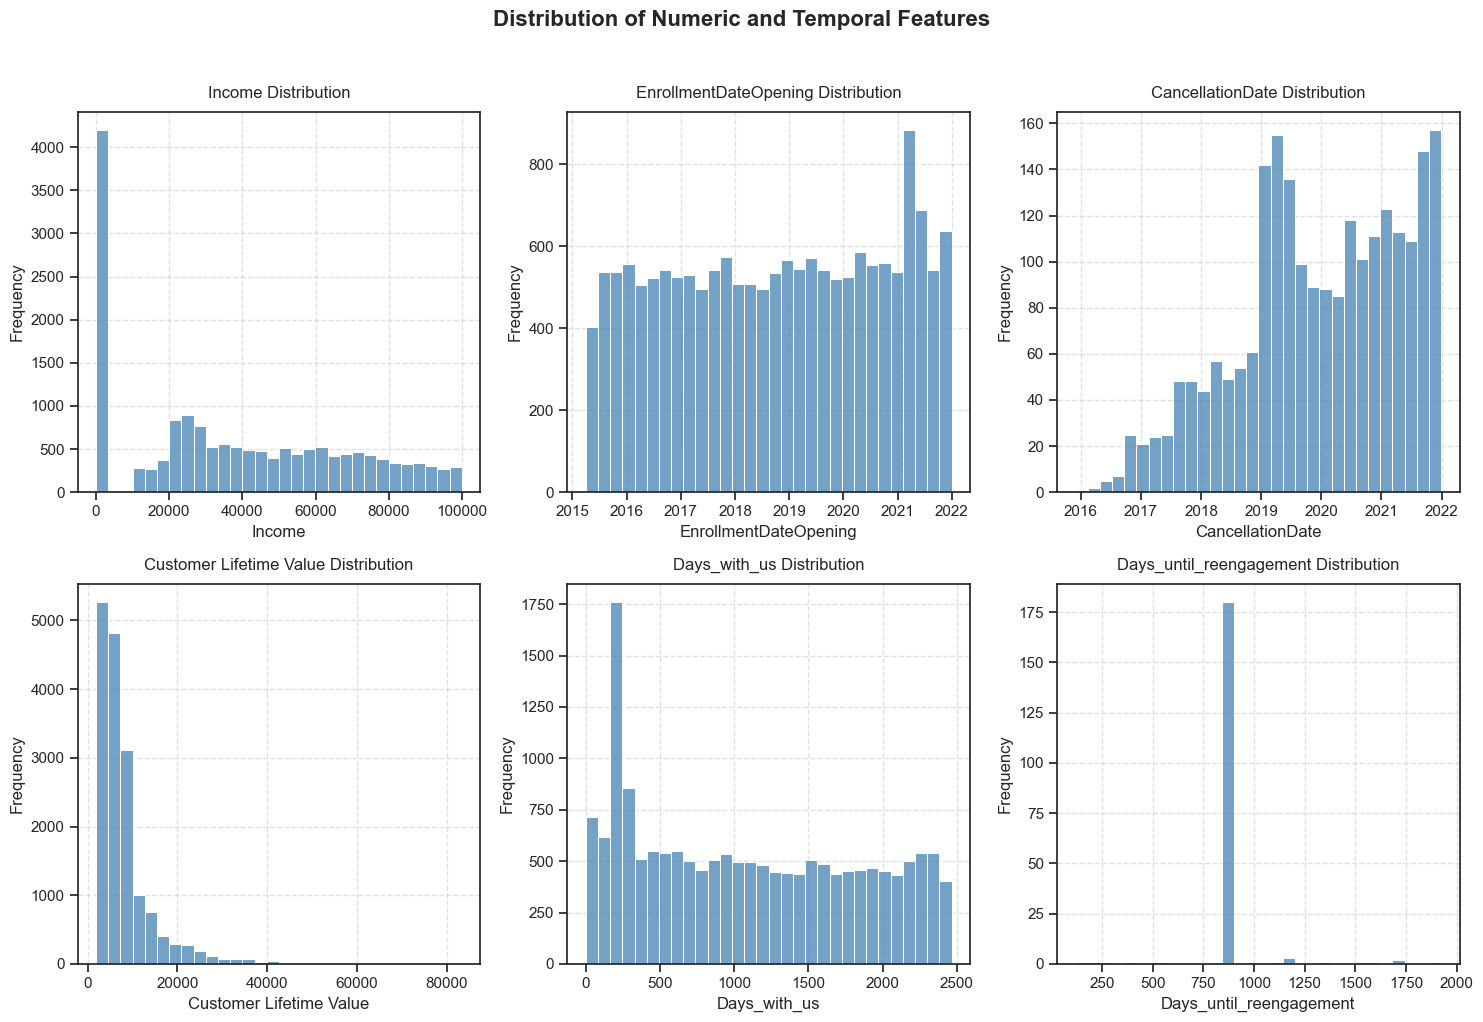

In [33]:
# Define rows and cols automatically based on number of features
sp_rows = 2
sp_cols = 3

# Create the figure
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(15, 10))
axes = axes.flatten()

# --- Plot Each Feature ---
for i, feat in enumerate(numeric_features_c):
    ax = axes[i]
    
    sns.histplot(df_AIAI_Customers_numeric[feat].dropna(), kde=False, ax=ax, bins=30, color="steelblue")
    ax.set_xlabel(feat)
    
    # Titles & formatting
    ax.set_title(f"{feat} Distribution", fontsize=12, pad=10)
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle='--', alpha=0.6)

# --- Layout & Global Title ---
plt.suptitle("Distribution of Numeric and Temporal Features", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

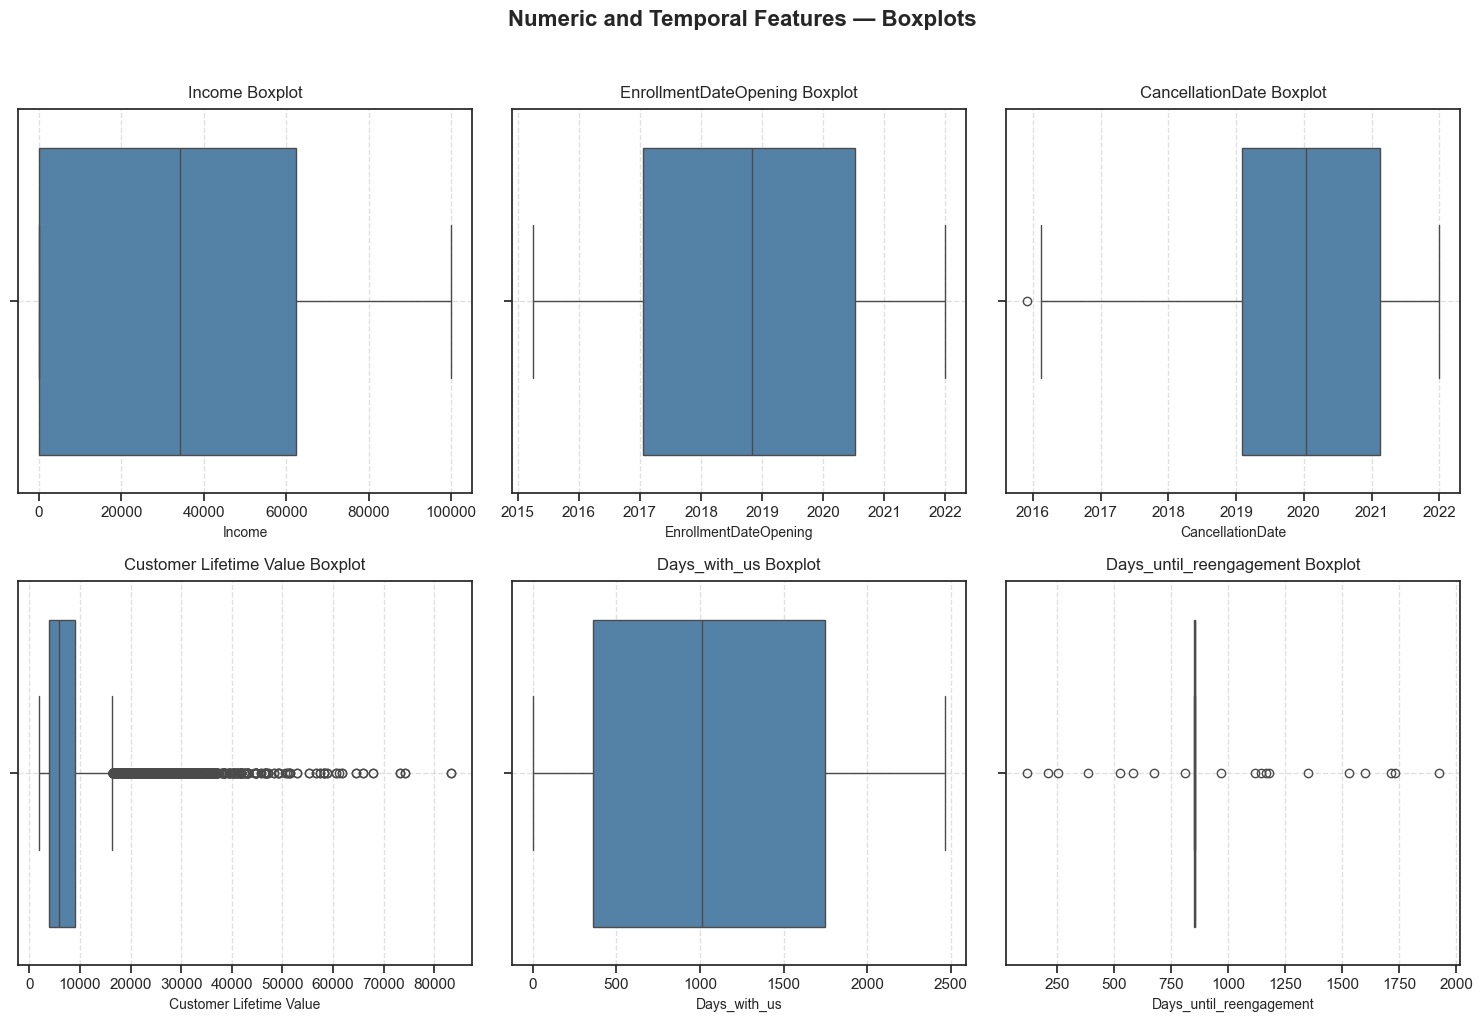

In [34]:
# --- Define subplot grid dynamically ---
sp_rows = 2
sp_cols = 3

fig, axes = plt.subplots(
    sp_rows, sp_cols,
    figsize=(15, 10),
    tight_layout=True
)
axes = axes.flatten()

# --- Plot each feature ---
for i, feat in enumerate(numeric_features_c):
    ax = axes[i]
    
    sns.boxplot(x=df_AIAI_Customers_numeric[feat].dropna(), ax=ax, color="steelblue")
    ax.set_xlabel(feat, fontsize=10)
    
    ax.set_title(f"{feat} Boxplot", fontsize=12, pad=8)
    ax.grid(True, linestyle='--', alpha=0.6)

# Hide any empty subplots (if number of features < grid slots)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numeric and Temporal Features — Boxplots", fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [35]:
# Compute Pearson correlation
corr = df_AIAI_Customers_numeric[numeric_features_c].corr(method="pearson")
# Round to 2 decimals for cleaner display
corr = corr.round(2)
corr

,Income,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,Days_with_us,Days_until_reengagement
Income,1.00,-0.00,-0.00,0.02,0.01,-0.07
EnrollmentDateOpening,-0.00,1.00,0.04,-0.00,-0.92,-0.16
CancellationDate,-0.00,0.04,1.00,0.01,-0.34,-0.94
Customer Lifetime Value,0.02,-0.00,0.01,1.00,-0.00,-0.05
Days_with_us,0.01,-0.92,-0.34,-0.00,1.00,0.16
Days_until_reengagement,-0.07,-0.16,-0.94,-0.05,0.16,1.00


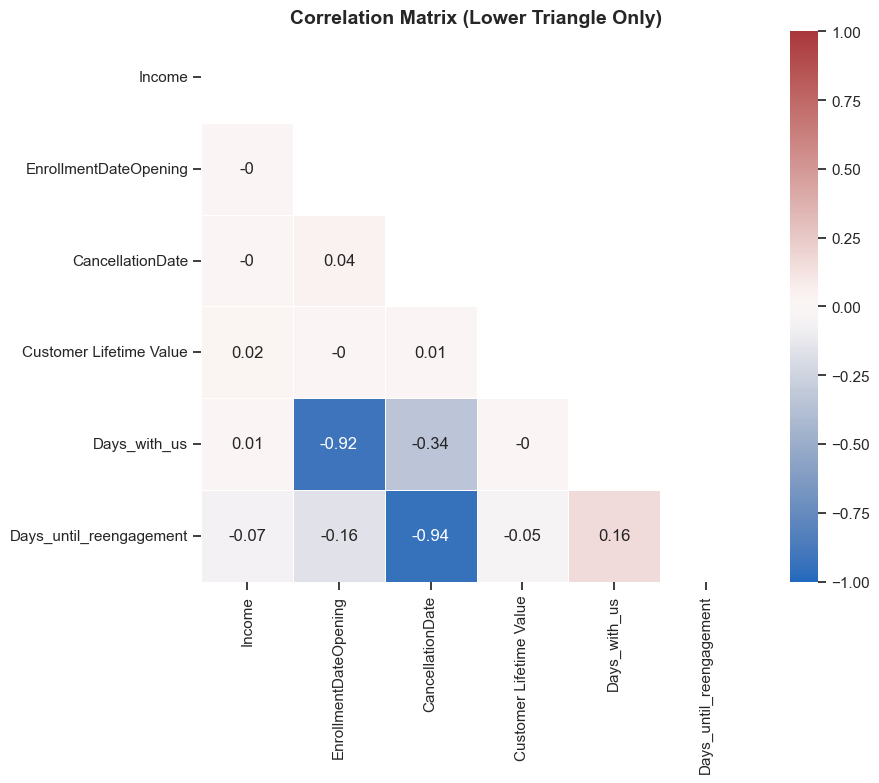

In [36]:
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

fig = plt.figure(figsize=(10, 8))

sns.heatmap(data=corr, 
            annot=True, 
            mask=mask, #aply the mask
            vmin=-1, vmax=1, 
            center=0, # Center the colormap at zero
            square=True, # Make each cell square-shaped
            linewidths=.5, # Add lines between cells
            cmap='vlag' # Diverging color map
            )

plt.title("Correlation Matrix (Lower Triangle Only)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


##### Categorical Features Visualizations

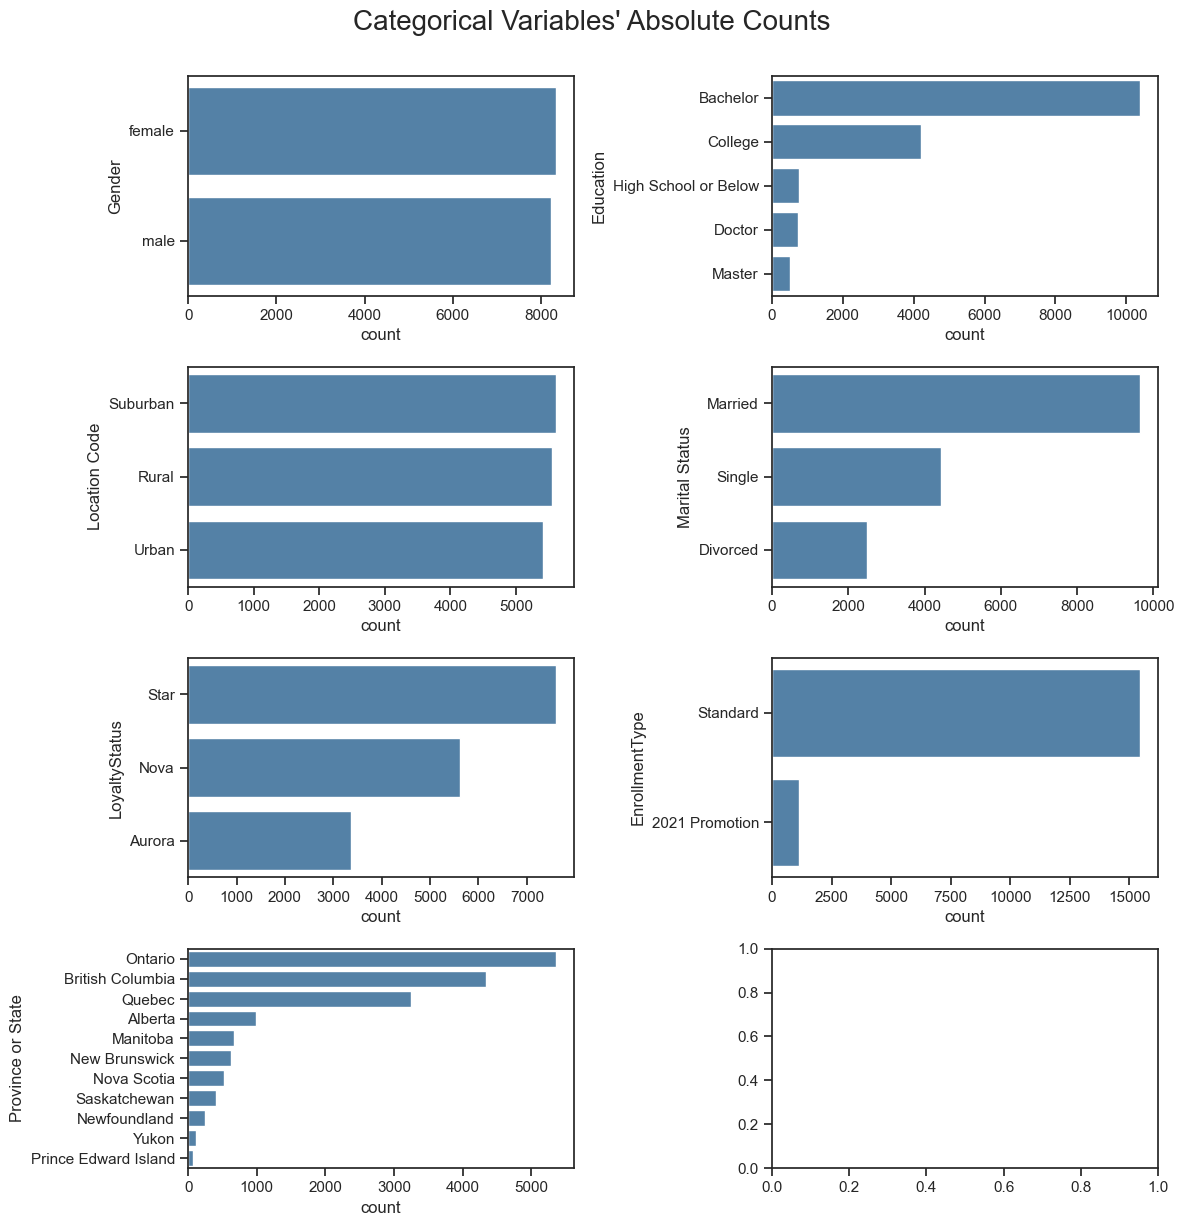

In [37]:
categorical_features_c = [
    'Gender',
    'Education',
    'Location Code',
    'Marital Status',
    'LoyaltyStatus',
    'EnrollmentType',
    'Province or State']

fig, axes = plt.subplots(
    4, 
    2, 
    figsize=(12, 12)
    )

for ax, feat in zip(axes.flatten(), categorical_features_c):
    sns.countplot(y=df_AIAI_Customers[feat], ax=ax, 
                  order=df_AIAI_Customers[feat].value_counts().index,
                  color= 'steelblue') 
    
plt.tight_layout(rect=[0, 0, 1, 0.98])

title="Categorical Variables' Absolute Counts"
plt.suptitle(title, fontsize=20, y=1.02)
plt.show()

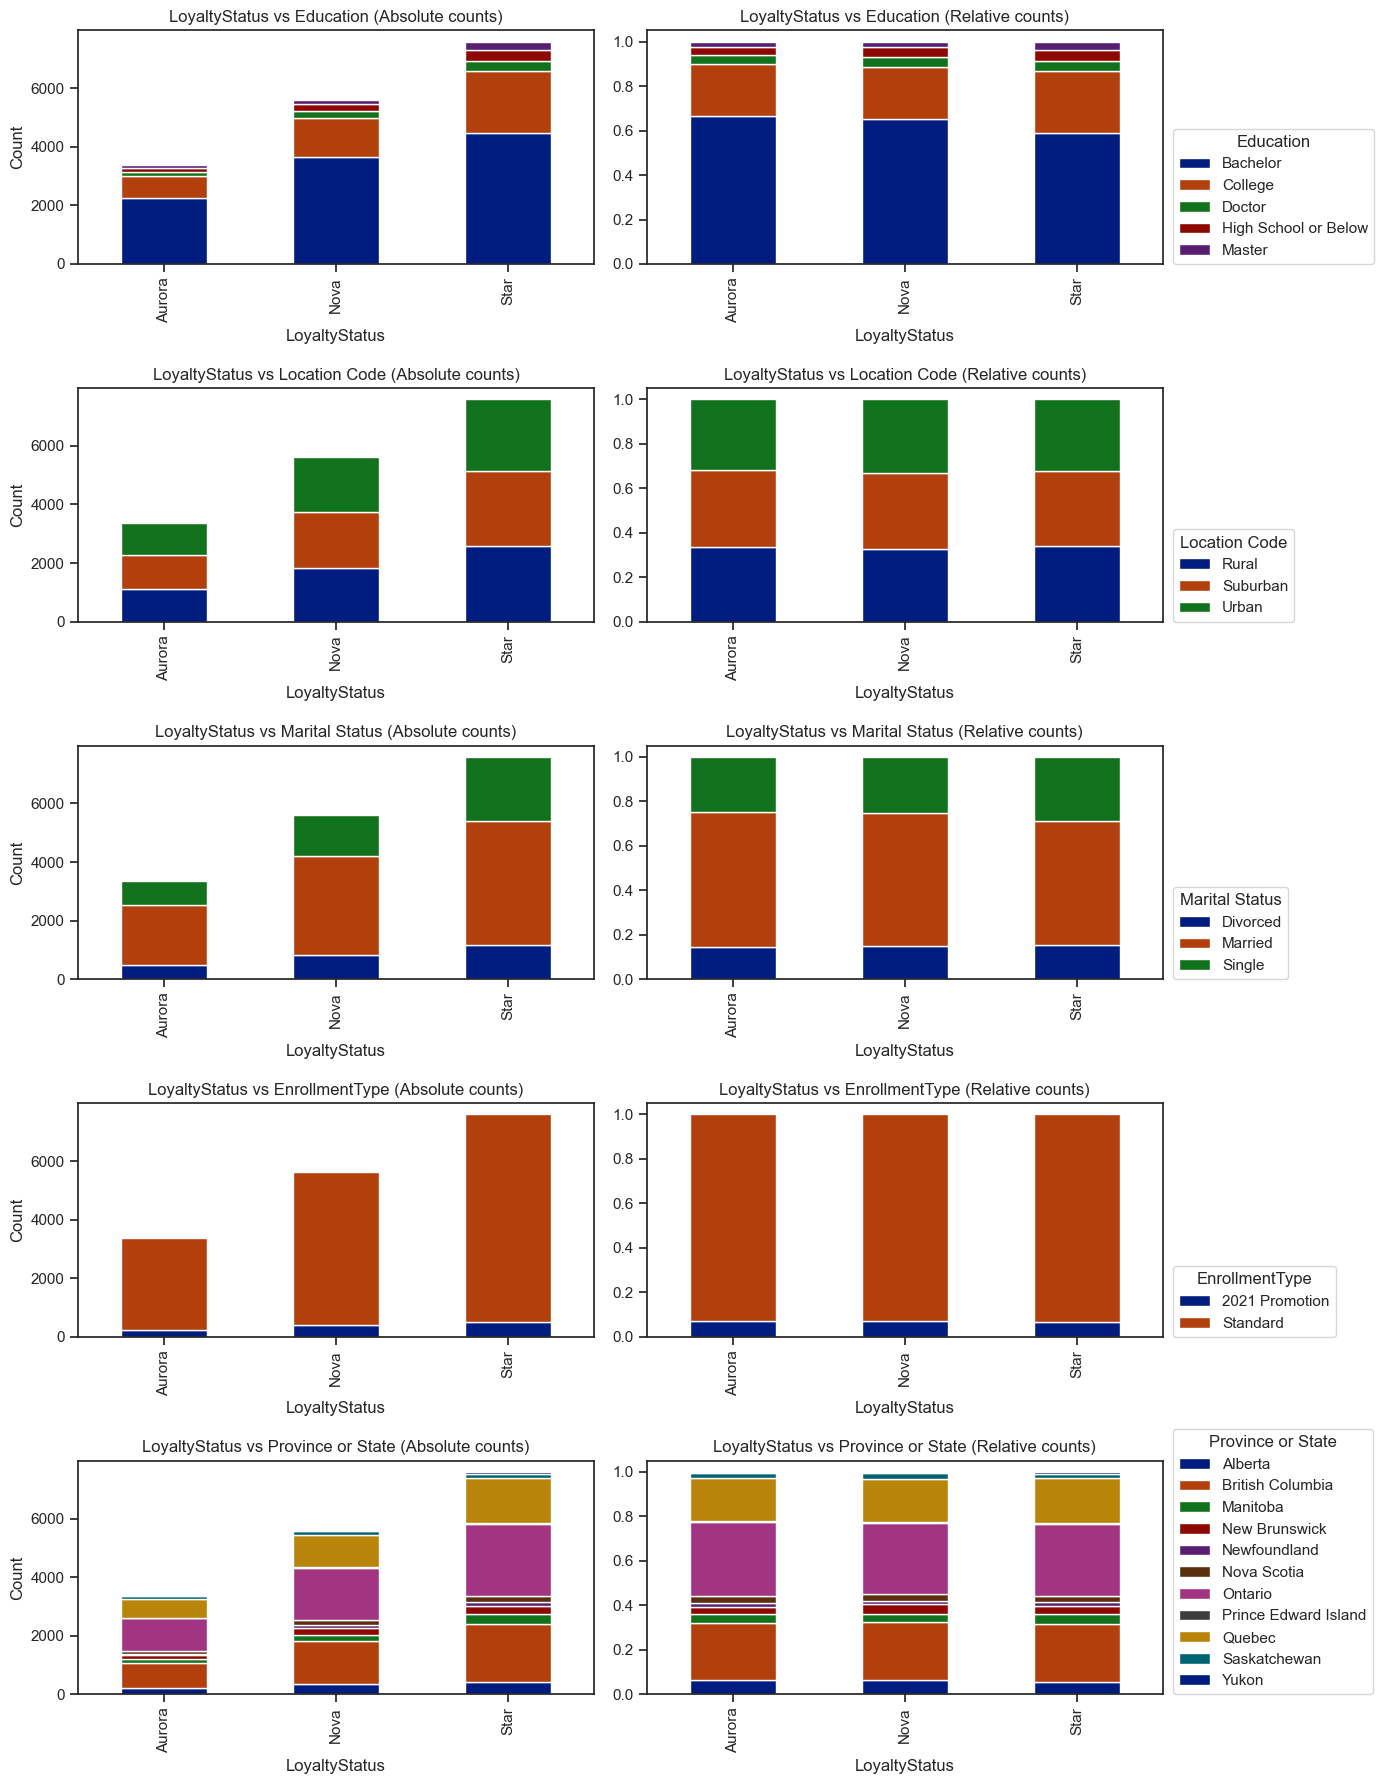

In [38]:
cat1 = 'LoyaltyStatus'

fig, axes = plt.subplots(5, 2, figsize=(14, 18))

cat_list = ['Education', 'Location Code', 'Marital Status', 'EnrollmentType', 'Province or State']

for row_index in range(5):
    cat2 = cat_list[row_index]
    for column_index in range(2):

        if column_index == 0:
            catpc_df = df_AIAI_Customers.groupby([cat1, cat2])[cat2].size().unstack()
            catpc_df.plot.bar(stacked=True, ax=axes[row_index, column_index], color = sns.color_palette("dark"))
            axes[row_index, column_index].set_ylabel('Count')
            axes[row_index, column_index].legend([], frameon=False)
        
        else:
            catpc_df = df_AIAI_Customers.groupby([cat1, cat2])[cat2].size() / df_AIAI_Customers.groupby([cat1])[cat2].size()
            catpc_df.unstack().plot.bar(stacked=True, ax=axes[row_index, column_index], color = sns.color_palette("dark"))
            axes[row_index, column_index].legend(title=cat2, loc=(1.02, 0))
            
        axes[row_index, column_index].set_title(f'LoyaltyStatus vs {cat2} ({"Absolute" if column_index == 0 else "Relative"} counts)')
        axes[row_index, column_index].set_xlabel('LoyaltyStatus')
        

plt.tight_layout()
plt.show()

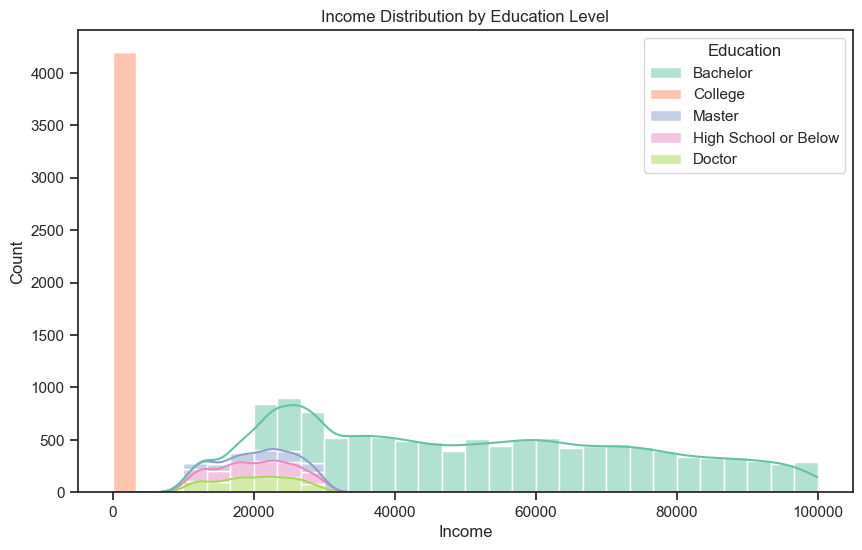

In [39]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_AIAI_Customers, x='Income', hue='Education', bins=30, kde=True, multiple='stack', palette='Set2')
plt.title("Income Distribution by Education Level")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

#### Customers DataFrame Visualization Interpretation

The numerical features look generally clean, but a few variables stand out. 
**Income** is heavily skewed because many records show zero income — all of these belong to customers with a *college* education. Other education levels (high school, bachelor’s, master’s, doctorate) have normal income values. This suggests a possible **data entry error or data leakage** that needs further investigation.  
**Days until re-engagement** is filled with outliers, hinting at inconsistent tracking or irregular updates.  
**Customer lifetime value (CLV)** has many high-end outliers, showing a few very valuable customers compared to the rest.

There’s a strong correlation (~0.93) between **days_with_us** and **days_until_reengagement**, which means one of them could be removed or merged to avoid redundancy. Other variables show weak correlations, adding independent information.

Categorical variables like **gender**, **location**, **loyalty status**, and **education** are fairly balanced. Most customers are from Ontario and belong to the Star loyalty tier.

Overall, the data is diverse and mostly clean, but a few fields — especially **income** and **re-engagement days** — need further review. The patterns suggest that **promotions and loyalty programs** after 2021 had a notable effect on customer engagement.


### **Flights DataFrame**

In [40]:
df_AIAI_Flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


In [41]:
df_AIAI_Flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [42]:
df_AIAI_Flights['Loyalty#'].nunique()

16737

In [43]:
df_AIAI_Flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

We have on total 608436 observations (records of flights), with 0 missing values, and more than 1 value per customer.

The data types are correct on almost every column, meaning that the values stores at least are of the data types that they are supouse to be.

It is only needed to change the data types of the date column YearMonthDate, and transform the colunm NumFlights and NumFlightsWithCompanions to integers, since they should be discrete.

#### **Duplicates**

In [44]:
df_AIAI_Flights.duplicated(keep=False).sum()
# We have 5778 duplicate rows

np.int64(5778)

We will only keep 1 record per each duplicate since it has the same information.

In [45]:
df_AIAI_Flights = df_AIAI_Flights.drop_duplicates(keep='first')

In [46]:
df_AIAI_Flights.duplicated(subset= ['Loyalty#', 'YearMonthDate'], keep=False).sum()

np.int64(5996)

We also saw that there are some times different records with multiple observations, we will group them and sum the values to have only 1 row per customer per month.

In [47]:
group_cols = ['Loyalty#', 'Year', 'Month', 'YearMonthDate']
agg_dict = {
    'NumFlights': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum',
    'DollarCostPointsRedeemed': 'sum'
}

# Group by the specified columns and aggregate the rest by summing
df_AIAI_Flights = df_AIAI_Flights.groupby(group_cols).agg(agg_dict).reset_index()

In [48]:
df_AIAI_Flights.duplicated(subset= ['Loyalty#', 'YearMonthDate'], keep=False).sum()

np.int64(0)

#### **Inconsistencies**

We will check for records that do not have any information (0 flights, 0 distance, 0 points...), to have only information of actual travels.

In [49]:
(df_AIAI_Flights['NumFlights'] == 0).sum()
# Almost half of the records have 0 flights

np.int64(300227)

In [50]:
((df_AIAI_Flights['NumFlights'] == 0) & (df_AIAI_Flights['DistanceKM'] == 0)).sum()

np.int64(294369)

In [51]:
(df_AIAI_Flights['DistanceKM'] == 0).sum()
# When NumFlights is 0, DistanceKM is also 0

np.int64(294369)

Since there are 301621 flights with 0 flights registered we will remove those zero values (a row was created but doesnt have a meaningfull information).

There were records (arround 5000, or aproximatly 2% of the 301621 observations with values) that had values for the distanceKM, but since we do not have information about the airports or routes we will simply remove them since whatever estimation that we will used will not be accurated.

In [52]:
# Remove inconsistency about 0 flights
df_AIAI_Flights = df_AIAI_Flights[~(df_AIAI_Flights['NumFlights'] == 0)]

Now lets fix the datatypes to the correct format.

In [53]:
# Round and convert float columns to integer
df_AIAI_Flights['NumFlights'] = df_AIAI_Flights['NumFlights'].round().astype(int)
df_AIAI_Flights['DistanceKM'] = df_AIAI_Flights['DistanceKM'].round().astype(int)
df_AIAI_Flights['NumFlightsWithCompanions'] = df_AIAI_Flights['NumFlightsWithCompanions'].round().astype(int)

# Converting into Datetime
df_AIAI_Flights['YearMonthDate'] = pd.to_datetime(df_AIAI_Flights['YearMonthDate'], format='%m/%d/%Y')

In [54]:
df_AIAI_Flights.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302305 entries, 0 to 602530
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Loyalty#                  302305 non-null  int64         
 1   Year                      302305 non-null  int64         
 2   Month                     302305 non-null  int64         
 3   YearMonthDate             302305 non-null  datetime64[ns]
 4   NumFlights                302305 non-null  int64         
 5   NumFlightsWithCompanions  302305 non-null  int64         
 6   DistanceKM                302305 non-null  int64         
 7   PointsAccumulated         302305 non-null  float64       
 8   PointsRedeemed            302305 non-null  float64       
 9   DollarCostPointsRedeemed  302305 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(6)
memory usage: 25.4 MB


There are only 302305 entries with actual information about flight history.

In [55]:
(df_AIAI_Flights['NumFlightsWithCompanions'] > df_AIAI_Flights['NumFlights']).sum()
# There are no cases where NumFlightsWithCompanions is greater than NumFlights

np.int64(0)

In [56]:
(round(df_AIAI_Flights['DistanceKM'] / 10) == df_AIAI_Flights['PointsAccumulated']).sum()
# The PointsAccumulated is aproximatly the DistanceKM divided by 10

np.int64(114451)

In [57]:
((df_AIAI_Flights['DistanceKM'] > 0) & (df_AIAI_Flights['PointsAccumulated'] == 0)).sum()
# No inconsistencies found where there are DistanceKM but no PointsAccumulated

np.int64(0)

In [58]:
(round(df_AIAI_Flights['PointsRedeemed'] / 100) == df_AIAI_Flights['DollarCostPointsRedeemed']).sum()
# The DollarCostPointsRedeemed is aproximatly PointsRedeemed divided by 100

np.int64(279928)

In [59]:
((df_AIAI_Flights['PointsRedeemed'] > 0) & (df_AIAI_Flights['DollarCostPointsRedeemed'] == 0)).sum()
# No inconsistencies found where there are PointsRedeemed but no DollarCostPointsRedeemed

np.int64(0)

In [60]:
df_AIAI_Flights['Loyalty#'].nunique()

15236

In [61]:
df_AIAI_Flights.describe().T

,count,mean,min,25%,50%,75%,max,std
Loyalty#,302305.0,548896.064716,100018.0,326699.0,549537.0,771307.0,999986.0,258219.624521
Year,302305.0,2020.049364,2019.0,2019.0,2020.0,2021.0,2021.0,0.825037
Month,302305.0,6.643536,1.0,4.0,7.0,10.0,12.0,3.449432
YearMonthDate,302305,2020-07-08 12:25:38.340417536,2019-01-01 00:00:00,2019-10-01 00:00:00,2020-08-01 00:00:00,2021-04-01 00:00:00,2021-12-01 00:00:00,NaN
NumFlights,302305.0,7.869714,1.0,4.0,7.0,11.0,39.0,4.587752
NumFlightsWithCompanions,302305.0,1.984827,0.0,0.0,1.0,4.0,20.0,2.462363
DistanceKM,302305.0,15673.570004,238.0,7828.0,15114.0,22641.0,78327.0,9458.28228
PointsAccumulated,302305.0,1567.04816,23.85,782.55,1511.0,2264.0,7831.0,945.810094
PointsRedeemed,302305.0,473.480723,0.0,0.0,0.0,0.0,8036.0,1354.28281
DollarCostPointsRedeemed,302305.0,4.679093,0.0,0.0,0.0,0.0,80.0,13.395916


Conclusions:
+ We have information from year 2019 to 2021 (3 years).
+ We have information from every month.
+ We see that we can use the DistanceKM to estimate the PointsAccumulated (PointsAccumulated = DistanceKM/10).
+ We see that we can use the PointsAccumulated to estimate the DollarCostPoints (DollarCostPoints = PointsAccumulated / 100).
+ We have information about 15236 unique customers, we will se which ones they are joining this dataset to the customer dataset, the missing Ids will have misisng values on those new joined columns and they only will have custers related to demografic atributes, being the same cluster for the rest of groups (Value-based segmentation, and Behavioral segmentation).
+ We see that on the DistanceKM variable the maximum is 78000 km, something that is not possible, we will solve this and create some limits before creating new features.

#### **Initial Visualizations**

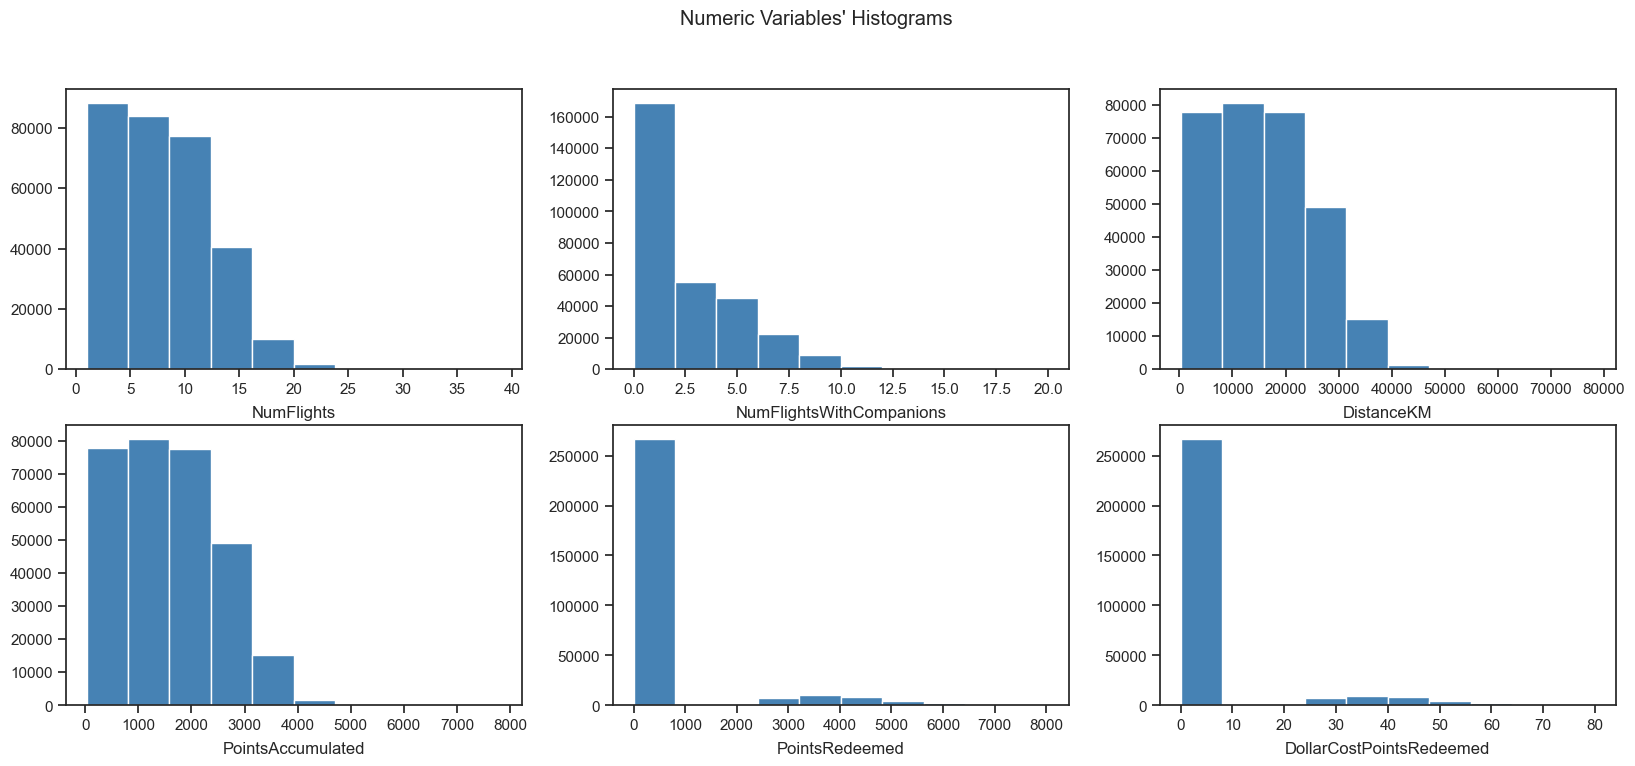

In [62]:
numeric_features_f = [
    'NumFlights',
    'NumFlightsWithCompanions',
    'DistanceKM',
    'PointsAccumulated',
    'PointsRedeemed',
    'DollarCostPointsRedeemed'
]

sp_rows = 2
sp_cols = 3

# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 8))

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), numeric_features_f): 
    ax.hist(df_AIAI_Flights[feat], color= 'steelblue')
    ax.set_title(feat, y=-0.2)
    
# Layout
# Add a centered title to the figure:
title = "Numeric Variables' Histograms"
plt.suptitle(title)

plt.show()

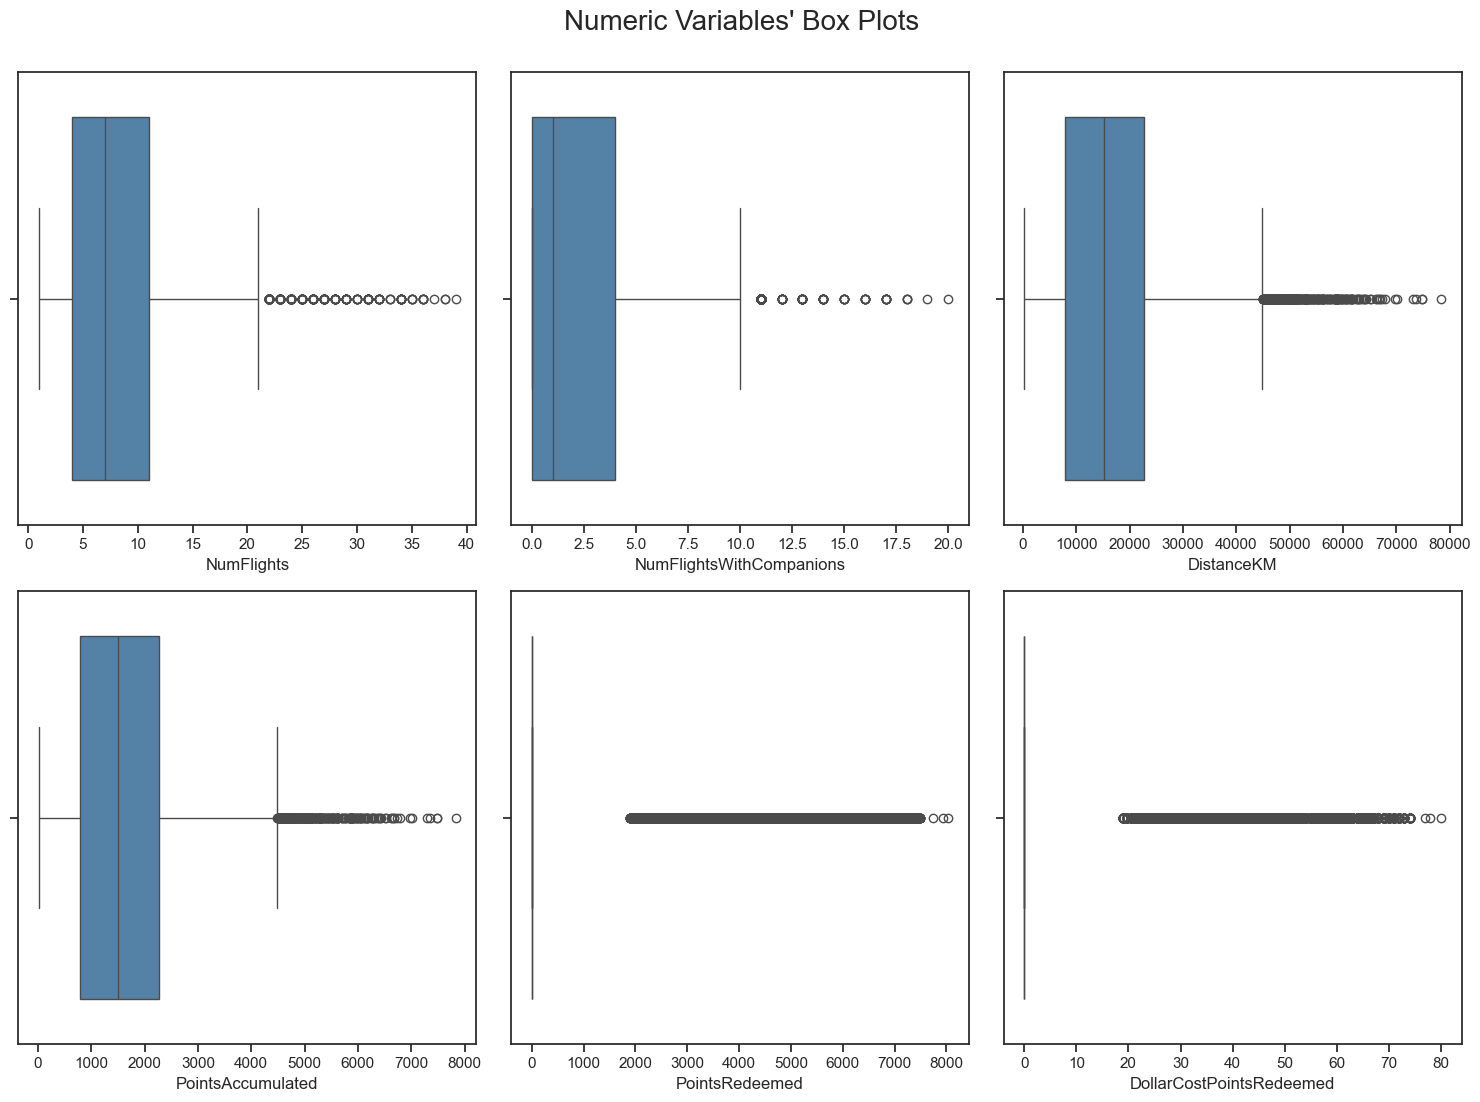

In [63]:
sp_rows = 2
sp_cols = ceil(len(numeric_features_f) / sp_rows)


# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(15, 11),
                         tight_layout=True
                        )

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), numeric_features_f): # Notice the zip() function and flatten() method
    sns.boxplot(x=df_AIAI_Flights[feat], ax=ax, color='steelblue')
    
# Layout
# Add a centered title to the figure:
title = "Numeric Variables' Box Plots"

plt.suptitle(title, fontsize=20, y=1)

plt.show()

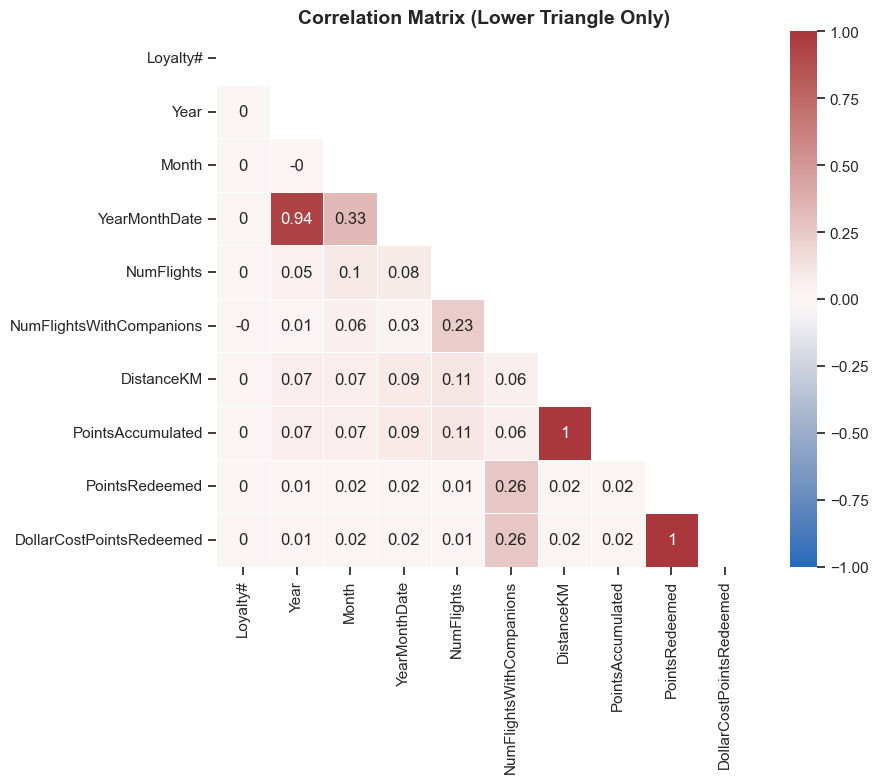

In [64]:
corr = df_AIAI_Flights.corr(method="pearson")
# Round to 2 decimals for cleaner display
corr = corr.round(2)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

fig = plt.figure(figsize=(10, 8))

sns.heatmap(data=corr, 
            annot=True, 
            mask=mask, #aply the mask
            vmin=-1, vmax=1, 
            center=0, # Center the colormap at zero
            square=True, # Make each cell square-shaped
            linewidths=.5, # Add lines between cells
            cmap='vlag' # Diverging color map
            )

plt.title("Correlation Matrix (Lower Triangle Only)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

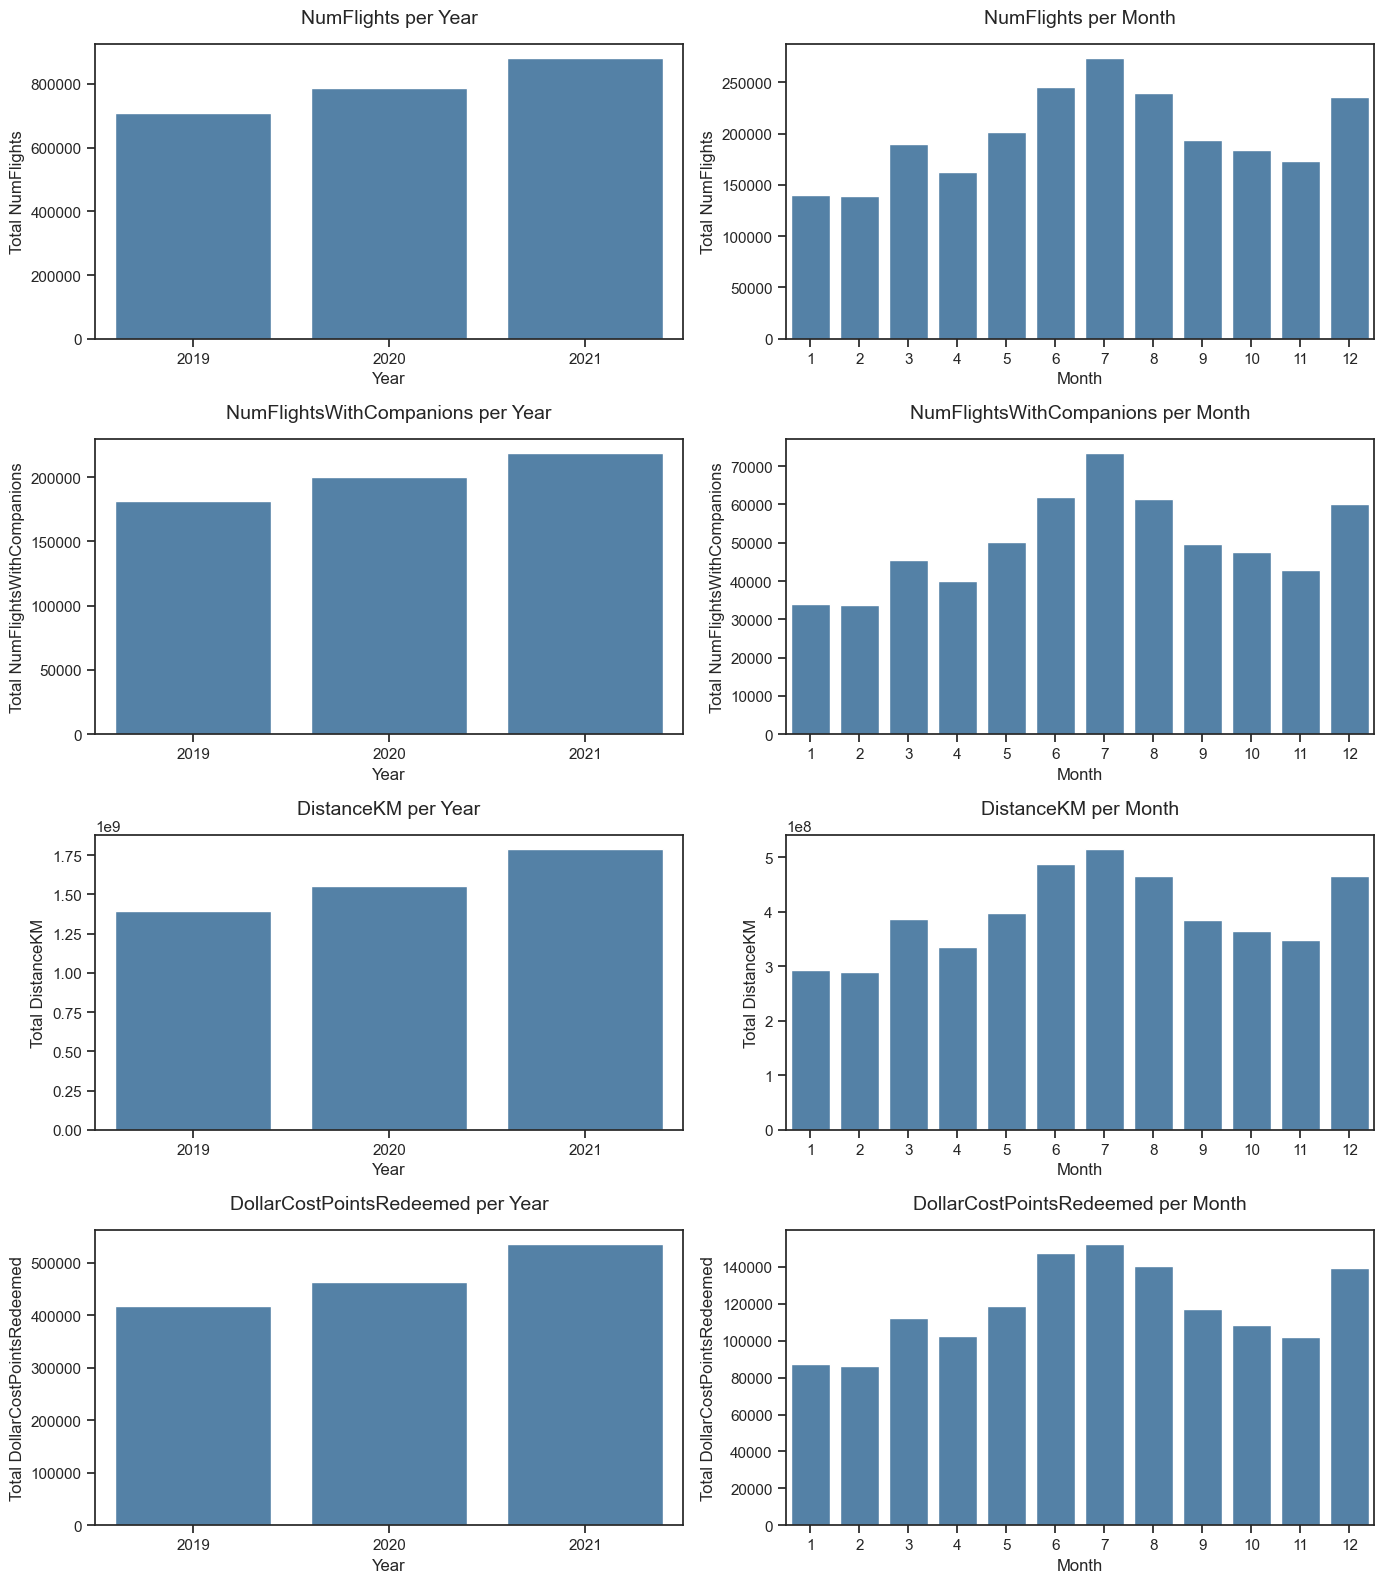

In [65]:
# Create aggregations
yearly_flights = df_AIAI_Flights.groupby('Year').agg({
    'NumFlights': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DistanceKM': 'sum',
    'DollarCostPointsRedeemed': 'sum'
})

m_flights = df_AIAI_Flights.groupby('Month').agg({'NumFlights': 'sum',
                                                      'NumFlightsWithCompanions': 'sum',
                                                      'DistanceKM': 'sum',
                                                      'DollarCostPointsRedeemed': 'sum'})

# Create figure with correct dimensions (4x2 instead of 5x2)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

metrics = ['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 'DollarCostPointsRedeemed']

for row_index, agg_col_name in enumerate(metrics):
    # Yearly plot (bar)
    sns.barplot(x=yearly_flights.index, y=yearly_flights[agg_col_name], 
                color='steelblue', ax=axes[row_index, 0])
    axes[row_index, 0].set_xlabel('Year')
    axes[row_index, 0].set_ylabel(f'Total {agg_col_name}')
    axes[row_index, 0].set_title(f'{agg_col_name} per Year', fontsize=14, pad=15)
    
    # Monthly plot (line)
    sns.barplot(x=m_flights.index, y=m_flights[agg_col_name], 
                color='steelblue', ax=axes[row_index, 1])
    axes[row_index, 1].set_xlabel('Month')
    axes[row_index, 1].set_ylabel(f'Total {agg_col_name}')
    axes[row_index, 1].set_title(f'{agg_col_name} per Month', fontsize=14, pad=15)


plt.tight_layout()
plt.show()

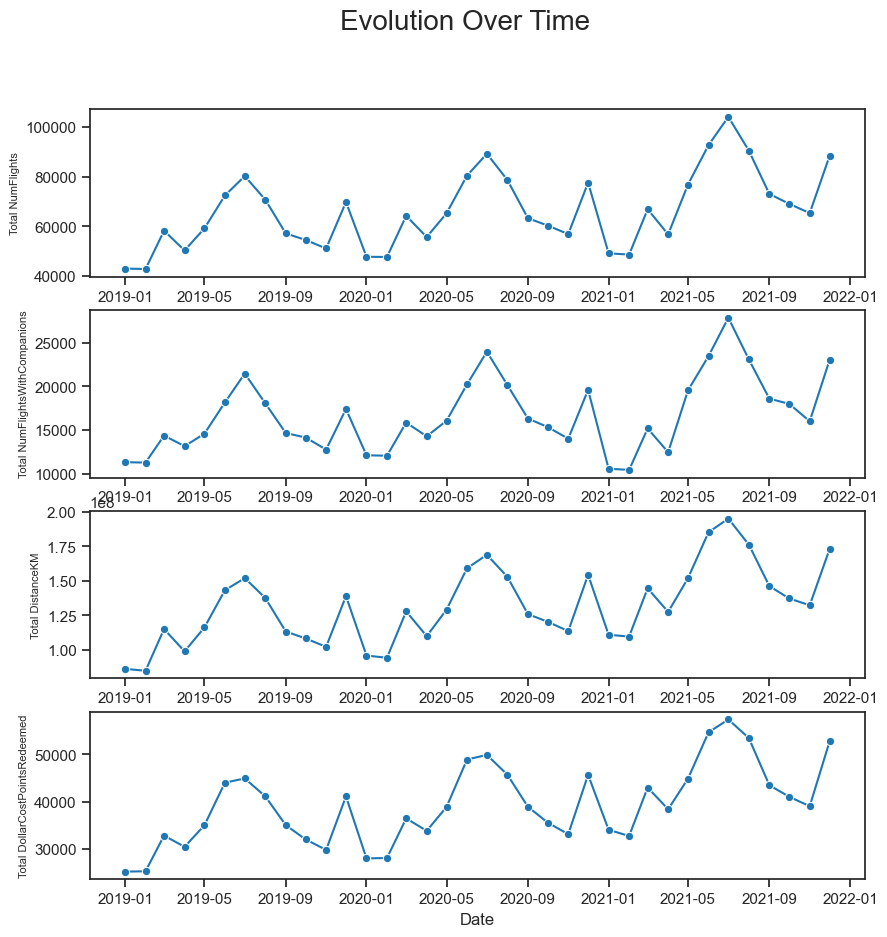

In [81]:
monthly_flights = df_AIAI_Flights.groupby('YearMonthDate').agg({
    'NumFlights': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DistanceKM': 'sum',
    'DollarCostPointsRedeemed': 'sum'
}).reset_index()

metrics = ['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 'DollarCostPointsRedeemed']

# Create figure with correct dimensions (4x2 instead of 5x2)
fig, axes = plt.subplots(4,1, figsize=(10, 10))

for ax, feat in zip(axes.flatten(), metrics): # Notice the zip() function and flatten() method
    sns.lineplot(data=monthly_flights, x='YearMonthDate', y=feat, 
                marker='o', ax=ax)
    ax.set_xlabel('Date')
    ax.set_ylabel(f'Total {feat}', fontsize = 8)


plt.suptitle(f'Evolution Over Time', fontsize=20)
plt.show()

#### Flights DataFrame Interpretation Visualization 

The numerical features show clear and logical trends. Customers with more *points accumulated* generally take more flights, while most customers fly only a few times. *Flights with companions* are unc ommon, indicating that most people travel alone.  
Both *points redeemed* and *dollar cost points redeemed* are mostly zero, suggesting that many customers either don’t earn enough points or choose not to redeem them.  

Box plots show strong *right-skewed distributions. **Distance_km* and *points accumulated* have many outliers from frequent travelers. *Points redeemed* and *dollar cost points redeemed* appear almost flat, with only a few extreme outliers — confirming that only a small group redeems points regularly.

There’s a strong correlation (~0.94) between *year* and *year_month, as they describe the same time frame. **Points accumulated* and *distance_km* are perfectly correlated (1.0), since points depend directly on distance. Similarly, *points redeemed* and *dollar cost points redeemed* are perfectly correlated, as one is calculated from the other. These relationships suggest some *redundant variables* that could be simplified or dropped.

Overall, the Flights data looks realistic: most customers fly rarely, don’t redeem points, and usually travel alone, while a small, highly active group contributes most of the total flights and points.

### **Joining the Datasets**

In [67]:
df_AIAI_Customers.index.isin(df_AIAI_Flights['Loyalty#'].unique()).sum()

np.int64(15101)

In [68]:
(~df_AIAI_Customers.index.isin(df_AIAI_Flights['Loyalty#'].unique())).sum()

np.int64(1471)

Only 15101 customers had a correspondance to the flight data, the rest (1471 customers) do not have travel data.

In [69]:
df_AIAI_Flights['Loyalty#'].isin(df_AIAI_Customers.index).sum()

np.int64(299345)

In [70]:
(~df_AIAI_Flights['Loyalty#'].isin(df_AIAI_Customers.index)).sum()

np.int64(2960)

We have a correspondance on 299345 records, only 2960 records do not have a customer associated, so these rows will not be used since they cannot be merged with a customer.

Since we do not have a 1:1 correspondance between table, to join these datasets we will need to perform some agregations on the flight dataset to have only 1 value per customer. More specifically we will create the following variables using the flight data, that will be helpfull to do some customer segmentation based on Value of the customer, Demographics and Habits/Behavioral, we will explaing better which other metrics we will use (that are already created):

**(Value Based)General Metrics**
- *Total_NumFlights:* - Total number of flights.
- *Total_DistanceKM:* - Total distance of flights on KM.
- *Perc_Flights_With_Companions:* - Percentage of flights with companions.
- *Dollar_Cost_Points_Remaining:* - Dollar value of points available for redemption.
- *Recency* - Days since last Purchase (if di not make any purchase should be Null).

**(Behavioral) Year Agregation**
- *Total_NumFlights_Per_Year:* - Total number of flights per year (one colum per year).
- *Total_DistanceKM_Per_Year:* - Total distance traveled per year on KM (one colum per year).
- *Perc_Flights_With_Companions_Per_Year:* - Percentage of flights with companions per year (one colum per year).
- *Dollar_Cost_Points_Remaining_Per_Year:* - Dollar value of points remaining per year (one colum per year).

**(Behavioral) Month Aggregation**
- *Total_NumFlights_Per_Month:* - Total number of flights per month (e.g.,Total_NumFlights_month_1).
- *Total_DistanceKM_Per_Month:* - Total distance traveled per month on KM.
- *Perc_Flights_With_Companions_Per_Month:* - Percentage of flights with companions per month.
- *Dollar_Cost_Points_Remaining_Per_Month:* - Dollar value of points remaining per month.

In [71]:
# First, filter out flights that don't have a corresponding customer
df_AIAI_Flights_cleaned = df_AIAI_Flights[df_AIAI_Flights['Loyalty#'].isin(df_AIAI_Customers.index)].copy()

#### Total Aggregations per Customer

In [72]:
# Define aggregations for total calculations
agg_dict_total = {
    'NumFlights': 'sum',
    'DistanceKM': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum',
    'YearMonthDate': 'max'
}

# Group by Loyalty# and aggregate to get total values
df_flights_agg = df_AIAI_Flights_cleaned.groupby('Loyalty#').agg(agg_dict_total)

# Rename columns for clarity
df_flights_agg.rename(columns={
    'NumFlights': 'Total_NumFlights',
    'DistanceKM': 'Total_DistanceKM',
    'NumFlightsWithCompanions': 'Total_NumFlights_With_Companions',
    'PointsAccumulated': 'Total_Points_Accumulated',
    'PointsRedeemed': 'Total_Points_Redeemed',
    'YearMonthDate': 'Last_Flight_Date',
}, inplace=True)

# --- Calculate Derived Metrics ---

# Calculate the percentage of flights with companions
# Use fillna(0) to handle cases where a customer has 0 flights (it should be in 0% of cases)
df_flights_agg['Perc_Flights_With_Companions'] = (
    (df_flights_agg['Total_NumFlights_With_Companions'] / df_flights_agg['Total_NumFlights']).fillna(0) * 100
)

# Calculate the dollar value of the remaining points
df_flights_agg['Dollar_Cost_Points_Remaining'] = (
    df_flights_agg['Total_Points_Accumulated'] - df_flights_agg['Total_Points_Redeemed']
) / 100

# Calculate Recency in days (last_day is the most recent day in the dataset that is 2021-12-30)
df_flights_agg['Recency_Days'] = (last_day - df_flights_agg['Last_Flight_Date']).dt.days

# Delete intermediate columns no longer needed
intermediate_cols = ['Total_NumFlights_With_Companions',
                     'Total_Points_Accumulated',
                     'Total_Points_Redeemed',
                     'Last_Flight_Date']

df_flights_agg.drop(columns=intermediate_cols, inplace=True)

# Display the first few rows of the resulting dataframe
df_flights_agg.head()

,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days
Loyalty#,,,,,
100018,231,530230,21.645022,324.5150,29
100102,248,339115,23.790323,151.4336,29
100140,217,432030,24.884793,382.9658,59
100214,112,364601,17.857143,235.4517,29
100272,187,429631,28.342246,320.6185,59


#### Yearly Aggregations

In [73]:
# Group by customer and year to get yearly totals
df_yearly_agg = df_AIAI_Flights_cleaned.groupby(['Loyalty#', 'Year']).agg(
    NumFlights_sum=('NumFlights', 'sum'),
    DistanceKM_sum=('DistanceKM', 'sum'),
    NumFlightsWithCompanions_sum=('NumFlightsWithCompanions', 'sum'),
    PointsAccumulated_sum=('PointsAccumulated', 'sum'),
    PointsRedeemed_sum=('PointsRedeemed', 'sum')
).reset_index()

# --- Pivoted Features (one column per year) ---

# Pivot for NumFlights
df_yearly_pivot_flights = df_yearly_agg.pivot_table(index='Loyalty#', columns='Year', values='NumFlights_sum', fill_value=0)
df_yearly_pivot_flights.columns = [f'Total_NumFlights_{year}' for year in df_yearly_pivot_flights.columns]

# Pivot for DistanceKM
df_yearly_pivot_distance = df_yearly_agg.pivot_table(index='Loyalty#', columns='Year', values='DistanceKM_sum', fill_value=0)
df_yearly_pivot_distance.columns = [f'Total_DistanceKM_{year}' for year in df_yearly_pivot_distance.columns]

# Pivot for NumFlightsWithCompanions
df_yearly_pivot_companions = df_yearly_agg.pivot_table(index='Loyalty#', columns='Year', values='NumFlightsWithCompanions_sum', fill_value=0)
df_yearly_pivot_companions.columns = [f'Total_NumFlights_With_Companions_{year}' for year in df_yearly_pivot_companions.columns]

# Pivot for PointsAccumulated
df_yearly_pivot_points_acc = df_yearly_agg.pivot_table(index='Loyalty#', columns='Year', values='PointsAccumulated_sum', fill_value=0)
df_yearly_pivot_points_acc.columns = [f'Total_Points_Accumulated_{year}' for year in df_yearly_pivot_points_acc.columns]

# Pivot for PointsRedeemed
df_yearly_pivot_points_red = df_yearly_agg.pivot_table(index='Loyalty#', columns='Year', values='PointsRedeemed_sum', fill_value=0)
df_yearly_pivot_points_red.columns = [f'Total_Points_Redeemed_{year}' for year in df_yearly_pivot_points_red.columns]


# Calculate Dollar Cost Points Remaining per year in the intermediate dataframe
df_yearly_agg['Dollar_Cost_Points_Remaining'] = (df_yearly_agg['PointsAccumulated_sum'] - df_yearly_agg['PointsRedeemed_sum']) / 100


# Merge all pivoted tables and summary table
df_yearly_features = pd.concat([
    df_yearly_pivot_flights,
    df_yearly_pivot_distance,
    df_yearly_pivot_companions,
    df_yearly_pivot_points_acc,
    df_yearly_pivot_points_red
], axis=1)

# Calculate percentage and dollar cost columns for the pivoted data
for year in df_AIAI_Flights_cleaned['Year'].unique():
    # Percentage of flights with companions per year
    num_flights_col = f'Total_NumFlights_{year}'
    companions_col = f'Total_NumFlights_With_Companions_{year}'
    perc_companions_col = f'Perc_Flights_With_Companions_{year}'
    
    if num_flights_col in df_yearly_features.columns and companions_col in df_yearly_features.columns:
        df_yearly_features[perc_companions_col] = (df_yearly_features[companions_col] / df_yearly_features[num_flights_col]).fillna(0) * 100

    # Dollar cost of points remaining per year
    points_acc_col = f'Total_Points_Accumulated_{year}'
    points_red_col = f'Total_Points_Redeemed_{year}'
    dollar_cost_col = f'Dollar_Cost_Points_Remaining_{year}'

    if points_acc_col in df_yearly_features.columns and points_red_col in df_yearly_features.columns:
        df_yearly_features[dollar_cost_col] = (df_yearly_features[points_acc_col] - df_yearly_features[points_red_col]) / 100

# Delete intermediate columns no longer needed
intermediate_cols = ['Total_NumFlights_With_Companions_2019',
                     'Total_NumFlights_With_Companions_2020',
                     'Total_NumFlights_With_Companions_2021',
                     'Total_Points_Accumulated_2019',
                     'Total_Points_Accumulated_2020',
                     'Total_Points_Accumulated_2021',
                     'Total_Points_Redeemed_2019', 
                     'Total_Points_Redeemed_2020',
                     'Total_Points_Redeemed_2021']

df_yearly_features.drop(columns=intermediate_cols, inplace=True)

# --- Sort Columns for Readability ---

# Get the unique years and sort them
years = sorted(df_AIAI_Flights_cleaned['Year'].unique())

# Define the base order of metrics
metric_order = [
    'Total_NumFlights',
    'Total_DistanceKM',
    'Perc_Flights_With_Companions',
    'Dollar_Cost_Points_Remaining'
]

# Create the list of sorted columns by metric, then by year
sorted_metric_cols = [f'{metric}_{year}' for metric in metric_order for year in years if f'{metric}_{year}' in df_yearly_features.columns]

# Reorder the DataFrame
df_yearly_features = df_yearly_features[sorted_metric_cols]

# Display the transposed head to verify the new order
df_yearly_features.head()

,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021
Loyalty#,,,,,,,,,,,,
100018,74.0,81.0,76.0,171693.0,190770.0,167767.0,20.270270,19.753086,25.000000,88.4250,98.20,137.89
100102,75.0,83.0,90.0,89410.0,99344.0,150361.0,22.666667,21.686747,26.666667,0.5436,0.57,150.32
100140,65.0,72.0,80.0,158995.0,176662.0,96373.0,24.615385,25.000000,25.000000,158.9958,176.61,47.36
100214,33.0,37.0,42.0,106067.0,117853.0,140681.0,9.090909,8.108108,33.333333,44.9217,49.88,140.65
100272,60.0,66.0,61.0,145103.0,161225.0,123303.0,28.333333,28.787879,27.868852,117.5985,130.62,72.40


#### Monthly Aggregations per Year

In [74]:
# Pivot: total number of flights per calendar month (1..12)
df_monthly_flights = df_AIAI_Flights_cleaned.pivot_table(
    index='Loyalty#',
    columns='Month',
    values='NumFlights',
    aggfunc='sum',
    fill_value=0
)
df_monthly_flights.columns = [f'Total_NumFlights_month_{int(c)}' for c in df_monthly_flights.columns]

# Pivot: total distance per calendar month
df_monthly_distance = df_AIAI_Flights_cleaned.pivot_table(
    index='Loyalty#',
    columns='Month',
    values='DistanceKM',
    aggfunc='sum',
    fill_value=0
)
df_monthly_distance.columns = [f'Total_DistanceKM_month_{int(c)}' for c in df_monthly_distance.columns]

# Pivot: flights with companions per calendar month
df_monthly_companions = df_AIAI_Flights_cleaned.pivot_table(
    index='Loyalty#',
    columns='Month',
    values='NumFlightsWithCompanions',
    aggfunc='sum',
    fill_value=0
)
df_monthly_companions.columns = [f'Total_NumFlights_With_Companions_month_{int(c)}' for c in df_monthly_companions.columns]

# Pivot: points accumulated and redeemed per calendar month (for dollar cost calc)
df_monthly_points_acc = df_AIAI_Flights_cleaned.pivot_table(
    index='Loyalty#',
    columns='Month',
    values='PointsAccumulated',
    aggfunc='sum',
    fill_value=0
)
df_monthly_points_acc.columns = [f'Total_Points_Accumulated_month_{int(c)}' for c in df_monthly_points_acc.columns]

df_monthly_points_red = df_AIAI_Flights_cleaned.pivot_table(
    index='Loyalty#',
    columns='Month',
    values='PointsRedeemed',
    aggfunc='sum',
    fill_value=0
)
df_monthly_points_red.columns = [f'Total_Points_Redeemed_month_{int(c)}' for c in df_monthly_points_red.columns]

# Combine monthly pivot tables
df_monthly_features = pd.concat([
    df_monthly_flights,
    df_monthly_distance,
    df_monthly_companions,
    df_monthly_points_acc,
    df_monthly_points_red
], axis=1).fillna(0)

# Derived monthly metrics:
# Percentage of flights with companions per month
for m in range(1, 13):
    flights_col = f'Total_NumFlights_month_{m}'
    companions_col = f'Total_NumFlights_With_Companions_month_{m}'
    perc_col = f'Perc_Flights_With_Companions_month_{m}'
    if flights_col in df_monthly_features.columns and companions_col in df_monthly_features.columns:
        # avoid division by zero
        df_monthly_features[perc_col] = (
            df_monthly_features[companions_col] / df_monthly_features[flights_col].replace(0, pd.NA)
        ).fillna(0) * 100
    else:
        df_monthly_features[perc_col] = 0

# Dollar cost of points remaining per month (points are converted to dollars by /100)
for m in range(1, 13):
    acc_col = f'Total_Points_Accumulated_month_{m}'
    red_col = f'Total_Points_Redeemed_month_{m}'
    dollar_col = f'Dollar_Cost_Points_Remaining_month_{m}'
    if acc_col in df_monthly_features.columns and red_col in df_monthly_features.columns:
        df_monthly_features[dollar_col] = (df_monthly_features[acc_col] - df_monthly_features[red_col]) / 100
    else:
        df_monthly_features[dollar_col] = 0


# Drop Columns no longer needed
intermediate_cols_name = []

for month_number in range(1, 13):
    intermediate_cols_name += [
        f'Total_NumFlights_With_Companions_month_{month_number}',
        f'Total_Points_Accumulated_month_{month_number}',
        f'Total_Points_Redeemed_month_{month_number}']
    
df_monthly_features.drop(columns=intermediate_cols_name, inplace=True)

# Inspect
df_monthly_features.head()

,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
100018,7,10,34,13,0,8,28,19,31,17,36,28,25677,32276,39395,32862,0,70351,73145,57431,38964,34674,65909,59546,0.000000,40.0,17.647059,0.000000,0.000000,25.000000,25.000000,47.368421,32.258065,23.529412,5.555556,21.428571,25.6700,32.2635,-26.5066,32.8587,0.0000,70.3443,73.1313,-52.4717,38.9598,4.8298,65.8986,59.5373
100102,19,6,29,26,7,8,14,27,27,20,30,35,20651,9713,11326,16844,15874,27263,38726,4965,60902,51597,19627,61627,42.105263,0.0,27.586207,23.076923,57.142857,0.000000,28.571429,0.000000,29.629630,55.000000,13.333333,17.142857,20.6421,9.7100,-97.7541,16.8281,15.8700,27.2600,38.7200,4.9617,60.8886,51.5960,19.6208,-16.9096
100140,20,0,15,23,20,15,22,11,39,4,19,29,18773,0,74694,5449,71077,28217,70995,3487,34297,3939,58383,62719,0.000000,0.0,66.666667,0.000000,50.000000,0.000000,77.272727,100.000000,5.128205,100.000000,0.000000,0.000000,18.7640,0.0000,74.6834,5.4412,22.1034,28.2034,70.9835,3.4815,34.2832,3.9300,58.3732,62.7190
100214,0,12,3,0,0,9,0,9,24,20,4,31,0,23770,20931,0,0,61847,0,81743,49484,32767,2709,91350,0.000000,0.0,100.000000,0.000000,0.000000,100.000000,0.000000,66.666667,0.000000,0.000000,50.000000,0.000000,0.0000,23.7636,20.9300,0.0000,0.0000,-7.7181,0.0000,81.7365,49.4779,32.7533,-56.8236,91.3321
100272,4,6,30,27,7,42,11,17,1,4,17,21,15015,47488,33571,17680,23616,71934,30408,76904,10555,19167,22181,61112,0.000000,50.0,13.333333,48.148148,14.285714,21.428571,0.000000,11.764706,0.000000,100.000000,35.294118,52.380952,15.0100,47.4744,-24.5019,17.6652,-27.2400,71.9268,30.4036,76.8882,10.5500,19.1600,22.1746,61.1076


#### **Flight Feature Merging**

Now we will join all the created feature sets into a single master dataframe. We will use a left join to ensure all customers from `df_AIAI_Customers` are retained, even if they don't have flight records.

In [75]:
# Start with the base customer dataframe
df_master = df_AIAI_Customers.copy()

# List of dataframes to join
feature_dfs = [
    df_flights_agg,
    df_yearly_features,
    df_monthly_features
]

# Sequentially join each feature dataframe
for feature_df in feature_dfs:
    df_master = df_master.join(feature_df, how='left')

# Display the shape and head of the final master dataframe
print("Shape of the master dataframe:", df_master.shape)

Shape of the master dataframe: (16572, 86)


In [76]:
df_master.head()

,First Name,Last Name,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Re_engaged_people,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,Cecilia,Householder,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,False,1049,<NA>,191.0,497375.0,29.319372,362.1394,29.0,59.0,64.0,68.0,116079.0,128976.0,252320.0,28.813559,29.687500,29.411765,94.4694,104.95,162.72,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610
549612,Dayle,Menez,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,False,1027,<NA>,279.0,389939.0,11.469534,165.2639,29.0,89.0,99.0,91.0,127972.0,142191.0,119776.0,7.865169,8.080808,18.681319,67.8339,75.33,22.10,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-157.8262,76.7735,24.3200,33.6881,35.8801,27.1500
429460,Necole,Hannon,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard,False,1274,<NA>,120.0,229821.0,33.333333,174.9763,363.0,54.0,60.0,6.0,97691.0,108547.0,23583.0,35.185185,35.000000,0.000000,71.7363,79.66,23.58,21.0,8.0,15.0,0.0,23.0,0.0,0.0,21.0,15.

In [77]:
# Save the dataframe to a CSV file
df_master.to_csv('../../data/DM_AIAI_MasterCustomerDB.csv')

In [78]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 86 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   First Name                             16572 non-null  object        
 1   Last Name                              16572 non-null  object        
 2   Customer Name                          16572 non-null  object        
 3   Province or State                      16572 non-null  object        
 4   City                                   16572 non-null  object        
 5   Latitude                               16572 non-null  float64       
 6   Longitude                              16572 non-null  float64       
 7   Postal code                            16572 non-null  object        
 8   Gender                                 16572 non-null  object        
 9   Education                              16572 non-null  objec

In [79]:
df_master.describe().T

,count,mean,min,25%,50%,75%,max,std
Latitude,16572.0,47.174612,42.984924,44.231171,46.087818,49.28273,60.721188,3.305572
Longitude,16572.0,-91.839905,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578,22.240873
Income,16572.0,37741.357531,0.0,0.0,34137.0,62375.0,99981.0,30357.279626
EnrollmentDateOpening,16572,2018-10-07 04:29:43.055756800,2015-04-01 00:00:00,2017-01-18 18:00:00,2018-11-02 00:00:00,2020-07-11 06:00:00,2021-12-30 00:00:00,NaN
CancellationDate,2245,2019-12-20 11:55:49.844098048,2015-11-30 00:00:00,2019-02-02 00:00:00,2020-01-14 00:00:00,2021-02-15 00:00:00,2021-12-30 00:00:00,NaN
Customer Lifetime Value,16572.0,7986.623409,1898.01,3979.1275,5780.18,8954.43,83325.38,6858.782006
Days_with_us,16572.0,1091.834661,0.0,358.75,1014.5,1745.0,2465.0,743.790065
Days_until_reengagement,199.0,866.60804,118.0,851.0,853.0,853.0,1924.0,174.068827
Total_NumFlights,15101.0,155.228329,1.0,109.0,170.0,207.0,349.0,70.654746
Total_DistanceKM,15101.0,308965.049202,473.0,216873.0,339853.0,412826.0,712730.0,141006.966186


**Variables for Clusters**

The variables: 'First Name', 'Last Name', 'Customer Name' will not be used to perform any clusters, we normally delete these variables to stablish some data protection measures but since this is not real data we will just keep it in our dataset without using them.

Based on the work that we will need to perform on the second phase of the project, we have 83 variables and we will explain in which type of preliminary segmentation they are going to be used:

**Value-Based Segmentation:**
*Groups customers by their economic value or profitability to the company.*

The variables are: 'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType', 'Re_engaged_people', 'Days_with_us', 'Days_until_reengagement', 'Total_NumFlights', 'Total_DistanceKM', 'Perc_Flights_With_Companions', 'Dollar_Cost_Points_Remaining', 'Recency_Days'.

The ones that probably we will **NOT** used on this cluster are: 'EnrollmentDateOpening', 'CancellationDate', 'Re_engaged_people'

**Behavioral Segmentation:** 
*Classifies customers based on their actions, habits, and engagement patterns with the brand.*

The variables are: All the total of flights, total distance, percentage of flights with companions and dollar cost points remaining, per **month and per year**.

**Demographic Segmentation:** 
*Divides customers according to personal and social characteristics such as age, gender, income, or location.*

The variables are: 'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code', 'Gender', 'Education', 'Location Code', 'Marital Status', 'Income'.

The ones that probably we will **NOT** used on this cluster are: 'Province or State', 'City', 'Postal code' and 'Location Code' (this will depend on the geographical analysis).

**Note:** The factor that we used to "remove" variables form the clusters are that they can be optaing using other variables (so we will remove them since they have a strong correlation). And we also know that for cluster we will need to remove some outliers (or apply some ceeling), fill some misisng data (even if is with 0), transform into numbers the categorical variables and scale the values.
